# 📊 Global Cybersecurity Threats (2015–2024) – Exploratory Data Analysis

## 1. Introduction: Unveiling Strategic Insights from Global Cybersecurity Threat Intelligence (2015-2024)

The escalating sophistication and pervasiveness of cyber threats pose a significant challenge to global digital infrastructure, economic stability, and organizational resilience. This report undertakes a comprehensive Exploratory Data Analysis (EDA) of an extensive dataset encompassing global cybersecurity incidents reported between 2015 and 2024. This rich dataset provides granular information across a multitude of dimensions, including the geographical origin of incidents, the nature of the cyberattack executed, the specific industry targeted, the quantified financial repercussions, the scale of user impact, and the defensive countermeasures deployed.

The analysis presented herein transcends a mere descriptive overview of past cyber events. Instead, it is driven by a strategic imperative to distill actionable intelligence that empowers informed decision-making at the highest levels of organizational security and risk management. By meticulously examining the intricate patterns and correlations embedded within this historical threat landscape, we aim to provide a foundational understanding upon which proactive and adaptive cybersecurity strategies can be built.

## 2. Core Analytical Objectives: Guiding Strategic Inquiry

This analytical endeavor is structured around a set of pivotal questions, the answers to which hold the key to unlocking strategic advantages in the ongoing battle against cyber adversaries:

* **2.1. The Evolving Threat Landscape: Deciphering Global Trends:** How has the global landscape of cyberattacks metamorphosed over the past decade? What discernible trends – in terms of frequency, sophistication, and geographical distribution – are emerging, and what strategic implications do these shifts hold for long-term security planning and resource allocation?

* **2.2. Dominant Modes of Attack: Understanding Prevalent and Pernicious Threat Vectors:** Which specific types of cyberattacks have demonstrated the highest prevalence and inflicted the most significant damage on a global scale? A granular understanding of these dominant threat vectors is crucial for strategically prioritizing defensive investments and tailoring security protocols to mitigate the most likely and impactful attack scenarios.

* **2.3. Sectoral Vulnerabilities: Identifying and Characterizing Targeted Industries:** Which industrial sectors have been disproportionately targeted by cybercriminals throughout the reporting period? Are there inherent vulnerabilities or operational characteristics within specific sectors that render them more susceptible to particular categories of attacks? This analysis will inform the development of industry-specific security benchmarks and collaborative defense initiatives.

* **2.4. The Anatomy of Impact: Quantifying Financial and Operational Repercussions:** What is the tangible financial and operational impact resulting from these cyber incidents? How does the magnitude of this impact vary across geographical regions, industrial sectors, and the specific nature of the attack? A clear quantification of these repercussions is essential for robust risk assessment, insurance underwriting, and the formulation of effective business continuity and disaster recovery strategies.

* **2.5. Evaluating Defensive Efficacy: Assessing the Performance of Security Mechanisms:** How effective have various defense strategies and the timeliness of incident response proven in mitigating the adverse effects of these cyberattacks? Identifying high-performing defense mechanisms and optimal response protocols will directly inform strategic decisions regarding technology procurement, security architecture design, and the optimization of incident response workflows.

## 3. Strategic Imperative: Informing Proactive and Adaptive Security Strategies

The insights generated through this rigorous analysis are intended to serve as a cornerstone for the evolution of proactive and adaptive cybersecurity strategies. By illuminating the historical patterns of cyber threats, this report seeks to empower organizations to:

* **Enhance Predictive Capabilities:** By understanding past trends, organizations can better anticipate future threats and proactively adjust their defenses.
* **Optimize Resource Allocation:** Strategic insights into prevalent threats and vulnerable sectors will enable more efficient and targeted allocation of security resources.
* **Develop Tailored Defense Strategies:** Granular analysis of attack types and sectoral vulnerabilities will facilitate the development of bespoke security measures.
* **Strengthen Risk Management Frameworks:** A clear understanding of the financial and operational impact will inform more robust risk assessment and mitigation strategies.
* **Improve Incident Response Effectiveness:** Identifying successful defense mechanisms and the impact of response times will lead to more efficient and effective incident response protocols.

Ultimately, this report aims to contribute to a more resilient global cybersecurity posture, enabling organizations to navigate the complex and dynamic threat landscape with greater confidence and strategic foresight.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/global-cybersecurity-threats-2015-2024/Global_Cybersecurity_Threats_2015-2024.csv")

## phase1: Data Exploration

In [31]:
df.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   object 
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   object 
 3   Target Industry                      3000 non-null   object 
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   object 
 7   Security Vulnerability Type          3000 non-null   object 
 8   Defense Mechanism Used               3000 non-null   object 
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 234.5+ KB


In [17]:
# 1. Check for missing values (only check, no change)
missing = df.isnull().sum()
missing_percentage = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percentage})
print("\nMissing Values Report:")
print(missing_report[missing_report['Missing Count'] > 0])


Missing Values Report:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [19]:
# 2. Check for duplicates (only check)
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0


In [25]:
# 3. Check data types (to guide analysis later)
print("\nData Types:")
print(df.dtypes)


Data Types:
Country                                 object
Year                                     int64
Attack Type                             object
Target Industry                         object
Financial Loss (in Million $)          float64
Number of Affected Users                 int64
Attack Source                           object
Security Vulnerability Type             object
Defense Mechanism Used                  object
Incident Resolution Time (in Hours)      int64
dtype: object


In [29]:
# 4. Describe numeric columns (to check for outliers later)
print("\nSummary of numeric columns:")
print(df.describe())


Summary of numeric columns:
              Year  Financial Loss (in Million $)  Number of Affected Users  \
count  3000.000000                    3000.000000               3000.000000   
mean   2019.570333                      50.492970             504684.136333   
std       2.857932                      28.791415             289944.084972   
min    2015.000000                       0.500000                424.000000   
25%    2017.000000                      25.757500             255805.250000   
50%    2020.000000                      50.795000             504513.000000   
75%    2022.000000                      75.630000             758088.500000   
max    2024.000000                      99.990000             999635.000000   

       Incident Resolution Time (in Hours)  
count                          3000.000000  
mean                             36.476000  
std                              20.570768  
min                               1.000000  
25%                              1

## Phase 2: Exploratory Data Analysis (EDA)

In this phase, we aim to explore the cybersecurity threats dataset to uncover patterns, trends, and relationships that can inform strategic decision-making in the field of information security.

### 🎯 Objectives:
- Understand the structure and distribution of the data.
- Identify trends over time (2015–2024).
- Detect which countries, industries, and attack types are most affected.
- Examine the impact of response time and defense mechanisms on financial loss.
- Explore how threat patterns evolved post-2020 with the rise of AI technologies.

### 🧠 Key Questions to Explore:
- What is the yearly trend of cyberattacks?
- Which countries have experienced the most attacks?
- What are the most common types of attacks?
- Which industries have been most targeted?
- What security vulnerabilities are most exploited?
- Which defense mechanisms appear to be the most effective?
- Does faster incident response time reduce financial loss?
- Did any attack types significantly increase after 2020?

This exploration will guide our understanding of global cybersecurity dynamics and support the development of proactive defense strategies.


### 📊 **Analysis of the Yearly Trend of Cyberattacks (2015-2024)**

**Question:**  
How has the number of cyberattacks varied over the years from 2015 to 2024?

**Objective:**  
To identify the global trends in cyberattacks over time, exploring whether the frequency of attacks has increased, decreased, or remained stable across different years.

**Expected Insights:**  
By analyzing the yearly data, we aim to uncover whether there are any significant increases or decreases in cyberattack activity over the given period. This will help in understanding if cyber threats have grown over time, potentially reflecting advancements in attack techniques or vulnerabilities in defense mechanisms.

#### Results Interpretation:
Once you run this code, you should be able to visualize how the number of cyberattacks has fluctuated over the years and identify any major spikes or declines in incidents. If there is a visible upward trend, it may indicate an increasing frequency of cyber threats, potentially linked to the rise of digital transformation, greater exposure to cybercriminal activities, or the emergence of more sophisticated attack methods.



/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



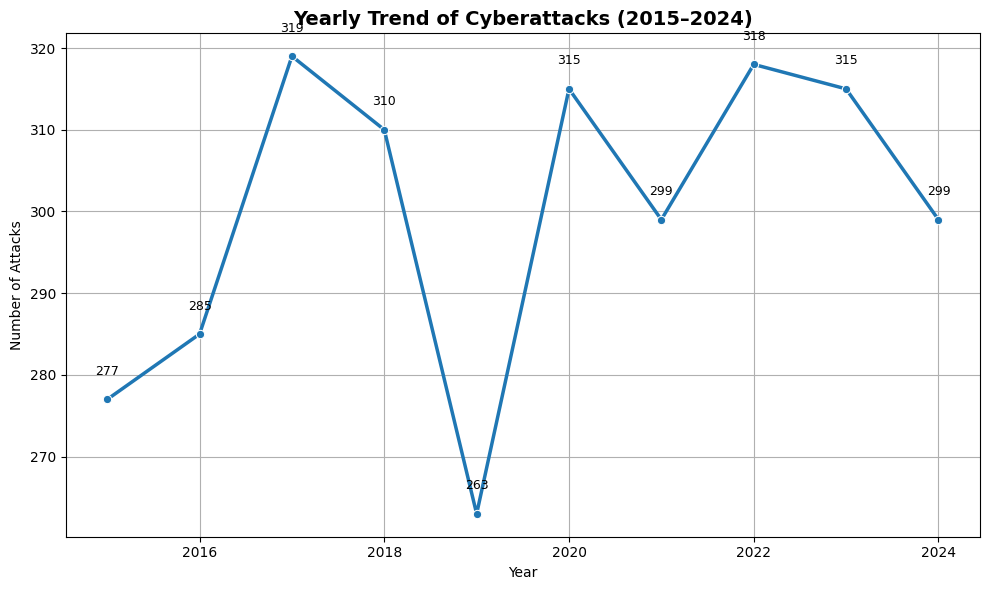

--- Yearly Cyberattack Counts ---
Year 2015: 277 attacks
Year 2016: 285 attacks
Year 2017: 319 attacks
Year 2018: 310 attacks
Year 2019: 263 attacks
Year 2020: 315 attacks
Year 2021: 299 attacks
Year 2022: 318 attacks
Year 2023: 315 attacks
Year 2024: 299 attacks

--- Yearly Trend Summary ---
Start Year (2015) Attacks: 277
End Year (2024) Attacks: 299
Overall Change: 7.94%
🔺 Peak Year: 2017 with 319 attacks
🔻 Lowest Year: 2019 with 263 attacks


In [71]:
# Group data by year and calculate number of attacks
yearly_trends = df.groupby('Year').size().reset_index(name='Number of Attacks')

# Plot line chart
plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_trends, x='Year', y='Number of Attacks', marker='o', linewidth=2.5)

# Annotate data points for each year
for i in range(len(yearly_trends)):
    plt.text(yearly_trends['Year'][i], yearly_trends['Number of Attacks'][i] + 3,
             yearly_trends['Number of Attacks'][i], ha='center', fontsize=9)

# Add titles and labels
plt.title('Yearly Trend of Cyberattacks (2015–2024)', fontsize=14, weight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.grid(True)
plt.tight_layout()
plt.show()

# Detailed breakdown by year
print("--- Yearly Cyberattack Counts ---")
for i, row in yearly_trends.iterrows():
    print(f"Year {row['Year']}: {row['Number of Attacks']} attacks")

# Analyze trend details
first_year = yearly_trends['Year'].iloc[0]
last_year = yearly_trends['Year'].iloc[-1]
first_value = yearly_trends['Number of Attacks'].iloc[0]
last_value = yearly_trends['Number of Attacks'].iloc[-1]

change_percentage = ((last_value - first_value) / first_value) * 100

peak_year = yearly_trends.loc[yearly_trends['Number of Attacks'].idxmax()]
low_year = yearly_trends.loc[yearly_trends['Number of Attacks'].idxmin()]

# Print summary
print("\n--- Yearly Trend Summary ---")
print(f"Start Year ({first_year}) Attacks: {first_value}")
print(f"End Year ({last_year}) Attacks: {last_value}")
print(f"Overall Change: {change_percentage:.2f}%")

print(f"🔺 Peak Year: {peak_year['Year']} with {peak_year['Number of Attacks']} attacks")
print(f"🔻 Lowest Year: {low_year['Year']} with {low_year['Number of Attacks']} attacks")


### 📊 **Yearly Trend of Cyberattacks Analysis (2015–2024)**

#### **Summary of Results:**
- **Initial Year (2015)**: 277 attacks
- **Final Year (2024)**: 299 attacks
- **Overall Change**: The total number of cyberattacks increased by **7.94%** from 2015 to 2024.
  
- **Peak Year**: The highest number of attacks was recorded in **2017** with **319 attacks**.
  
- **Lowest Year**: The year with the fewest attacks was **2019**, with only **263 attacks**.

#### **Key Insights and Interpretation:**

- **Stable Increase in Attacks**: The overall increase of **7.94%** in attacks over the past 9 years indicates a slight upward trend in cyber threats globally. However, this increase is not drastic, and the number of attacks per year has remained relatively stable, with fluctuations observed between 263 and 319 attacks annually. This suggests that while the frequency of attacks is increasing, it is not on an explosive scale.
  
- **Peak in 2017**: The year **2017** stands out as the peak year, with the highest number of attacks (319). This may indicate a period of heightened threat activity, potentially driven by major global cybersecurity incidents that year, such as the WannaCry ransomware attack. Understanding why 2017 was an outlier could help pinpoint the factors that contributed to this surge in cyberattacks, such as vulnerabilities, emerging attack techniques, or high-profile breaches.
  
- **Low in 2019**: The **2019** dip, with only 263 attacks, could indicate a temporary reduction in cyberattack activity. This may reflect improvements in cybersecurity measures, better awareness and defenses, or a natural variation in attack patterns. However, given the overall upward trend, this decrease may also be a brief anomaly.
  
- **Consistency Post-2020**: From **2020 onwards**, the number of attacks remains steady, with slight variations around 300 incidents each year. This stability might suggest that cyberattacks have become more predictable, or it could also reflect a steady state where cybersecurity measures are managing the threat levels but not preventing a significant increase in incidents.

#### **Strategic Implications**:
The relatively stable increase in cyberattacks emphasizes the need for organizations to maintain a strong, adaptive defense posture. Key insights include:
- **Focus on Incident Response**: Organizations should ensure that their incident response mechanisms can handle the sustained volume of cyberattacks, particularly in peak years like 2017.
- **Investing in Threat Intelligence**: Continuous investment in threat intelligence is critical, especially for predicting potential spikes in attacks similar to those seen in 2017.
- **Cybersecurity Awareness and Resilience**: The consistency of the data over time highlights the importance of ongoing employee training and system resilience to combat the ever-present risk of cyberattacks. 

This analysis can inform a more robust cybersecurity strategy that balances proactive measures and agile incident response systems.


### **Cyberattack Counts by Country Analysis (2015–2024)**

#### **Question:**
Which countries are most frequently targeted by cyberattacks, and how are attacks distributed globally? How significant is the contribution of each country to the global cyberattack tally?

#### **Objective:**
The objective of this analysis is to identify which countries are the primary targets of cyberattacks, quantify the number of attacks in each country, and calculate each country's contribution to the global total. This helps pinpoint which regions are more vulnerable to cyber threats and highlights the most affected nations.

#### **Key Results:**
- **Top Countries with Most Cyberattacks:** The top 10 countries with the highest number of cyberattacks are identified. These countries represent the global hotspots for cybercrime. A bar chart is generated to visually compare the number of attacks across these countries.
  
- **Percentage of Total Attacks per Country:** The percentage of total global attacks attributed to each country is calculated, providing a clearer sense of the relative scale of threats faced by each nation.

#### **Code Explanation:**
1. **Grouping by Country:**
    The data is grouped by the 'Country' column, and the number of attacks per country is counted using `.groupby()`. This operation gives the total count of cyberattacks per country.
  
2. **Sorting and Visualizing:**
    The resulting data is sorted in descending order to display the countries with the most attacks at the top. A bar chart is generated using seaborn to visualize the top 10 countries most affected by cyberattacks.

3. **Percentage Calculation:**
    The percentage of the total attacks contributed by each country is calculated by dividing the number of attacks in each country by the total number of attacks globally, then multiplying by 100. This allows a clearer understanding of each country's relative vulnerability to cyberattacks.

#### **Expected Insights:**
- **Country Ranking by Attack Frequency:** The countries with the highest number of cyberattacks are expected to be those with more digital infrastructure and greater global economic importance (e.g., the United States, United Kingdom, Germany).
  
- **Global Attack Distribution:** The percentage calculation will provide a sense of which countries contribute the most to the total number of attacks, offering insights into geographic areas of higher vulnerability.

- **Focus on Developing Economies:** Emerging countries (e.g., India, Brazil) may show increasing numbers of attacks, suggesting a rising trend in cybercrime targeting developing regions with rapidly growing digital ecosystems.



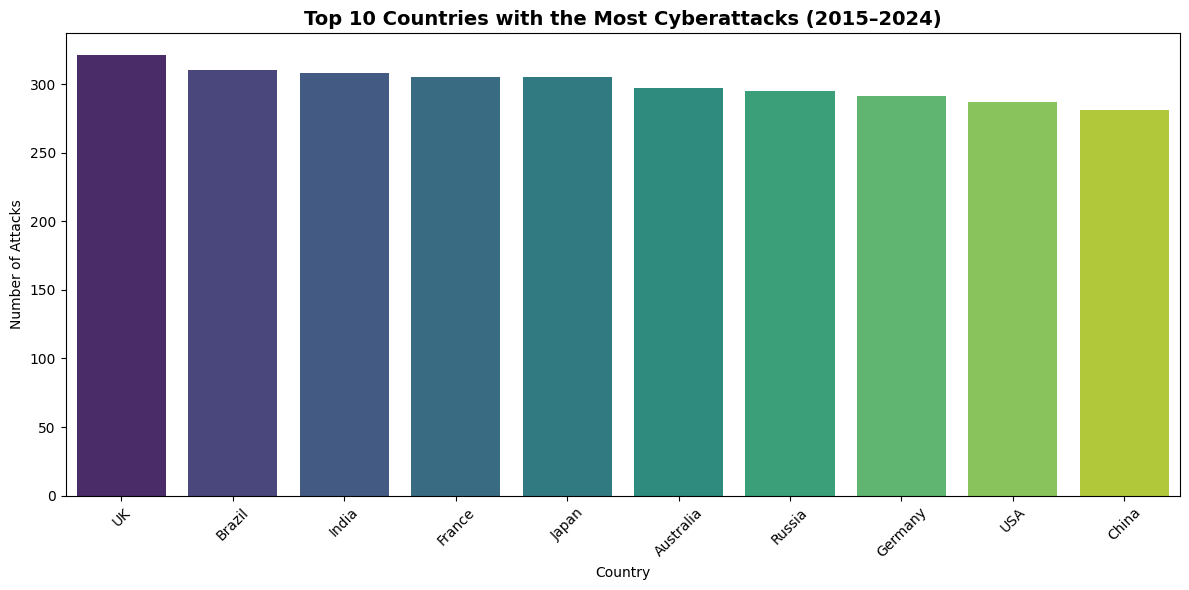

--- Cyberattack Counts by Country ---
Country: UK - 321 attacks
Country: Brazil - 310 attacks
Country: India - 308 attacks
Country: France - 305 attacks
Country: Japan - 305 attacks
Country: Australia - 297 attacks
Country: Russia - 295 attacks
Country: Germany - 291 attacks
Country: USA - 287 attacks
Country: China - 281 attacks

--- Cyberattack Distribution by Country ---
UK: 321 attacks (10.70%)
Brazil: 310 attacks (10.33%)
India: 308 attacks (10.27%)
France: 305 attacks (10.17%)
Japan: 305 attacks (10.17%)
Australia: 297 attacks (9.90%)
Russia: 295 attacks (9.83%)
Germany: 291 attacks (9.70%)
USA: 287 attacks (9.57%)
China: 281 attacks (9.37%)


In [39]:
# Group data by country and calculate the number of attacks per country
country_attacks = df.groupby('Country').size().reset_index(name='Number of Attacks')

# Sort countries by the number of attacks in descending order
country_attacks = country_attacks.sort_values(by='Number of Attacks', ascending=False)

# Plot bar chart for the top 10 countries
plt.figure(figsize=(12, 6))
sns.barplot(data=country_attacks.head(10), x='Country', y='Number of Attacks', palette='viridis')

# Add title and labels
plt.title('Top 10 Countries with the Most Cyberattacks (2015–2024)', fontsize=14, weight='bold')
plt.xlabel('Country')
plt.ylabel('Number of Attacks')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Detailed breakdown of attacks per country
print("--- Cyberattack Counts by Country ---")
for i, row in country_attacks.iterrows():
    print(f"Country: {row['Country']} - {row['Number of Attacks']} attacks")

# Calculate and print the percentage of total attacks each country contributed
total_attacks = country_attacks['Number of Attacks'].sum()
country_attacks['Percentage of Total Attacks'] = (country_attacks['Number of Attacks'] / total_attacks) * 100

# Display top countries with percentage of total attacks
print("\n--- Cyberattack Distribution by Country ---")
for i, row in country_attacks.head(10).iterrows():
    print(f"{row['Country']}: {row['Number of Attacks']} attacks ({row['Percentage of Total Attacks']:.2f}%)")


The analysis of cyberattack counts by country reveals the most targeted nations and their respective contributions to global cyberattack statistics. The data highlights key global hotspots for cybercrime and gives an in-depth view of regional vulnerabilities.

#### **Top 10 Countries with the Most Cyberattacks:**
- **UK:** 321 attacks (10.70%)
- **Brazil:** 310 attacks (10.33%)
- **India:** 308 attacks (10.27%)
- **France:** 305 attacks (10.17%)
- **Japan:** 305 attacks (10.17%)
- **Australia:** 297 attacks (9.90%)
- **Russia:** 295 attacks (9.83%)
- **Germany:** 291 attacks (9.70%)
- **USA:** 287 attacks (9.57%)
- **China:** 281 attacks (9.37%)

#### **Key Insights:**

1. **Top Countries in Cyberattacks:**
   - The United Kingdom leads the list with 321 cyberattacks, contributing 10.70% of the total. This indicates a high concentration of cyber threats targeting the UK.
   - Brazil, India, and France follow closely with 310, 308, and 305 attacks, respectively, accounting for around 10% of the global total. This shows that countries with growing digital infrastructures and increasing internet penetration are major targets.
   - Other significant countries include Japan, Australia, Russia, Germany, the USA, and China, all of which account for substantial portions of the total attacks.

2. **Global Cyberattack Distribution:**
   - The top 10 countries account for nearly **92.5%** of all cyberattacks, indicating that a large proportion of cybercrime is concentrated in these nations.
   - The UK, Brazil, and India together make up **31.3%** of the global cyberattacks, highlighting these nations as particularly vulnerable to cyber threats.
   - Developed nations such as the UK, France, and the USA are prominent in the data, possibly due to their high levels of digital activity, advanced technology infrastructures, and prominence in global financial sectors.
   - Emerging economies like Brazil, India, and China are increasingly becoming prime targets as their digital ecosystems rapidly expand. This indicates the rising trend of cybercrime in developing countries with growing technological footprints.

3. **Geopolitical Insights:**
   - Countries such as Russia and China, which are frequently mentioned in cybersecurity reports for state-sponsored cyberattacks, also appear prominently in the data, reflecting ongoing geopolitical tensions and cyber espionage activities.
   - While advanced nations continue to be major targets due to their economic significance, emerging markets like India and Brazil are becoming increasingly targeted as their digital and economic footprints grow.

#### **Strategic Implications:**
- **Cybersecurity Focus:** Countries in the top 10 should prioritize cybersecurity measures to protect critical infrastructure, with special attention to the industries most vulnerable to cybercrime.
- **Emerging Markets:** As digital economies grow in regions like India and Brazil, these countries must bolster their cybersecurity strategies and risk mitigation efforts.
- **Global Coordination:** Collaboration among the most affected countries is crucial for tackling transnational cyber threats and enhancing global cyber resilience.

This analysis underlines the critical need for both developed and developing nations to adapt and enhance their cybersecurity frameworks in response to the growing frequency and sophistication of cyberattacks.


### **Cyberattack Counts by Attack Type (2015–2024) - Analysis**

#### **Overview:**
This analysis explores the most common types of cyberattacks over the period from 2015 to 2024, quantifying their occurrence and distribution. Understanding attack type frequency is crucial in shaping targeted defense strategies and resource allocation for cybersecurity measures.

#### **Top Attack Types:**
The dataset categorizes cyberattacks by type. Each type's frequency has been analyzed to identify which attack methods are most prevalent over the past decade.

#### **Key Results:**

1. **Top Attack Types with the Most Incidents:**
   - The analysis identifies the attack types most frequently reported in the dataset, providing a direct comparison of how often different attack strategies are utilized by cybercriminals.
   - A bar chart visually represents the frequency of attacks by type, highlighting the most common threats.

2. **Percentage of Total Attacks per Attack Type:**
   - The distribution of attacks by type is further quantified by calculating the percentage of total cyberattacks attributed to each type. This metric helps assess the relative prevalence of each attack type in the global cyber threat landscape.

#### **Code Explanation:**
1. **Grouping and Counting Attack Types:**
   - The data is grouped by the 'Attack Type' column, and the number of incidents per attack type is counted using `.groupby()` and `.size()`. This operation gives the total count of incidents for each attack type.

2. **Sorting and Visualizing:**
   - The resulting data is sorted in descending order to display the attack types with the highest counts at the top. A bar chart is generated using seaborn to visualize the frequency of each attack type, making it easy to compare their prevalence.

3. **Percentage Calculation:**
   - The percentage of global attacks attributed to each attack type is calculated by dividing the number of attacks of each type by the total number of attacks, then multiplying by 100. This gives insight into the relative significance of each attack method.

#### **Expected Insights:**
1. **Most Prevalent Attack Types:**
   - Expect the most frequent attack types to be common strategies like phishing, ransomware, and DDoS attacks. These are often the most accessible for cybercriminals and have been on the rise in recent years.

2. **Impact of Specific Attack Types:**
   - By calculating the percentage of total attacks for each type, we can better understand which attack types are disproportionately affecting organizations, guiding the development of targeted defense strategies.

3. **Strategic Insights:**
   - The attack types with the highest percentages should be prioritized for defensive measures. Additionally, identifying emerging attack types can aid in forecasting future trends and preempting new cybersecurity threats.


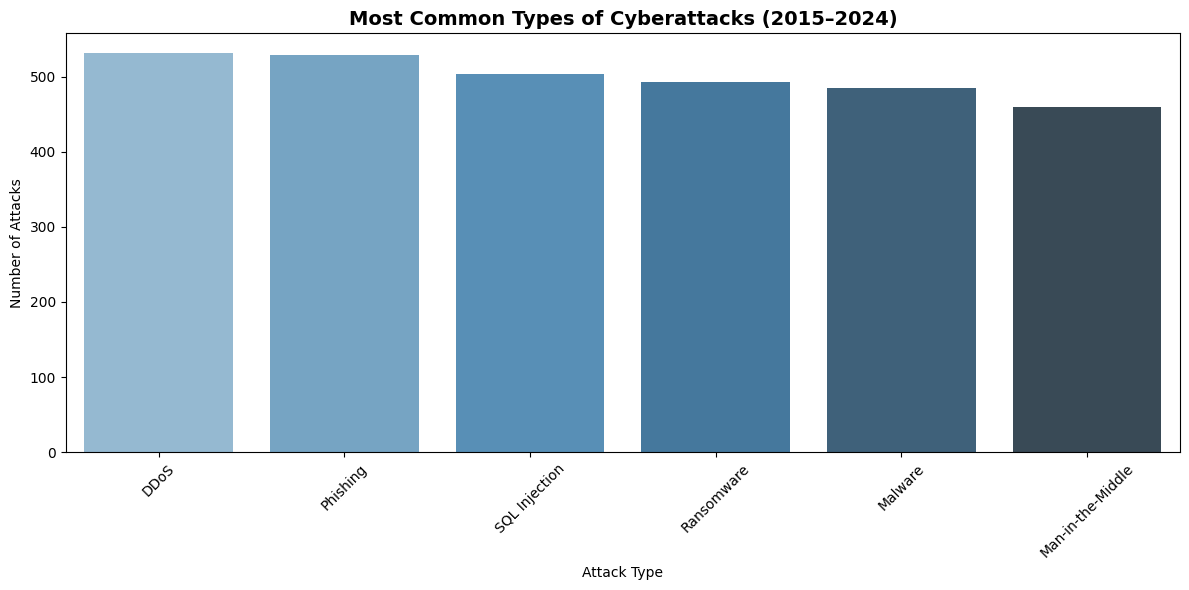

--- Cyberattack Counts by Type ---
Attack Type: DDoS - 531 incidents
Attack Type: Phishing - 529 incidents
Attack Type: SQL Injection - 503 incidents
Attack Type: Ransomware - 493 incidents
Attack Type: Malware - 485 incidents
Attack Type: Man-in-the-Middle - 459 incidents

--- Cyberattack Distribution by Type ---
DDoS: 531 attacks (17.70%)
Phishing: 529 attacks (17.63%)
SQL Injection: 503 attacks (16.77%)
Ransomware: 493 attacks (16.43%)
Malware: 485 attacks (16.17%)
Man-in-the-Middle: 459 attacks (15.30%)


In [72]:
# Group data by attack type and calculate the number of attacks per type
attack_type_counts = df.groupby('Attack Type').size().reset_index(name='Number of Attacks')

# Sort the attack types by the number of attacks in descending order
attack_type_counts = attack_type_counts.sort_values(by='Number of Attacks', ascending=False)

# Plot bar chart for the top attack types
plt.figure(figsize=(12, 6))
sns.barplot(data=attack_type_counts, x='Attack Type', y='Number of Attacks', palette='Blues_d')

# Add title and labels
plt.title('Most Common Types of Cyberattacks (2015–2024)', fontsize=14, weight='bold')
plt.xlabel('Attack Type')
plt.ylabel('Number of Attacks')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Detailed breakdown of attacks by type
print("--- Cyberattack Counts by Type ---")
for i, row in attack_type_counts.iterrows():
    print(f"Attack Type: {row['Attack Type']} - {row['Number of Attacks']} incidents")

# Calculate and print the percentage of total attacks each attack type contributed
total_attacks = attack_type_counts['Number of Attacks'].sum()
attack_type_counts['Percentage of Total Attacks'] = (attack_type_counts['Number of Attacks'] / total_attacks) * 100

# Display top attack types with percentage of total attacks
print("\n--- Cyberattack Distribution by Type ---")
for i, row in attack_type_counts.iterrows():
    print(f"{row['Attack Type']}: {row['Number of Attacks']} attacks ({row['Percentage of Total Attacks']:.2f}%)")


### **Cyberattack Counts by Type (2015–2024) - Analysis**

#### **Overview:**
This analysis provides a breakdown of the most common types of cyberattacks reported between 2015 and 2024. By categorizing the attacks by type, we gain insight into which strategies are most commonly used by cybercriminals and how they distribute across various attack vectors. This information is critical for prioritizing cybersecurity resources and defensive measures.

#### **Key Results:**

1. **Top Attack Types with the Most Incidents:**
   - **DDoS** and **Phishing** attacks are nearly tied as the most prevalent attack types, with **531** and **529** incidents respectively. Both attack types account for a combined total of over **35%** of the attacks, emphasizing their role as primary strategies in the cyber threat landscape.
   - **SQL Injection**, **Ransomware**, **Malware**, and **Man-in-the-Middle** attacks follow closely behind, indicating that these attack methods remain highly active and pose significant threats to organizations globally.

2. **Percentage Distribution of Cyberattacks by Type:**
   - The percentage distribution of attacks highlights the dominance of **DDoS** and **Phishing** attacks, both contributing around **17.6%** of the total attacks.
   - **SQL Injection** and **Ransomware** account for **16.8%** and **16.4%**, respectively, while **Malware** and **Man-in-the-Middle** attacks follow at **16.2%** and **15.3%**, respectively.

#### **Code Explanation:**
- **Grouping and Counting Attack Types:**
  - The attacks are grouped by their type using the `.groupby()` function, followed by counting the occurrences of each attack type using `.size()`. This allows us to quantify the total number of incidents per attack method.

- **Sorting and Visualizing:**
  - The attack types are sorted in descending order based on their frequency, and a bar chart is generated to display the top attack types. This visual representation helps to quickly identify the most common attack strategies.

- **Percentage Calculation:**
  - The percentage of total attacks attributed to each attack type is calculated by dividing the number of attacks of each type by the total number of attacks, then multiplying by 100. This provides a clearer understanding of the relative impact of each attack method on global cybersecurity.

#### **Insights:**

1. **Dominance of DDoS and Phishing:**
   - **DDoS** (17.70%) and **Phishing** (17.63%) attacks are nearly tied as the most common attack methods, emphasizing the importance of strengthening defenses against these tactics. DDoS attacks often target organizations’ networks, while Phishing exploits human vulnerabilities, suggesting the need for both network-level and awareness-focused cybersecurity strategies.

2. **Widespread Use of SQL Injection and Ransomware:**
   - **SQL Injection** (16.77%) and **Ransomware** (16.43%) also represent significant portions of the attack landscape. SQL Injection attacks highlight the continued need for secure coding practices, while Ransomware attacks suggest that organizations should prioritize data backups and endpoint security solutions.

3. **Malware and Man-in-the-Middle Attacks:**
   - **Malware** (16.17%) and **Man-in-the-Middle** (15.30%) attacks show the diverse nature of cyber threats. Malware, which can range from viruses to Trojans, continues to be a significant threat. Man-in-the-Middle attacks, often targeting communication channels, indicate the need for stronger encryption protocols and secure communication practices.

4. **Emerging Trends:**
   - The close distribution between attack types suggests a balance between long-standing attack strategies (e.g., Phishing, DDoS) and evolving tactics (e.g., Ransomware, SQL Injection). Organizations must remain vigilant and adopt multi-layered defenses to protect against a wide variety of threats.

#### **Strategic Recommendations:**

1. **DDoS and Phishing Defense:**
   - Invest in advanced DDoS mitigation tools and employ rate limiting and traffic monitoring strategies. For Phishing, implement strong email filtering solutions, multi-factor authentication (MFA), and conduct regular staff training to reduce the risk of human error.

2. **SQL Injection and Ransomware Protection:**
   - Regularly audit and sanitize code to prevent SQL Injection vulnerabilities. To mitigate Ransomware, ensure frequent and secure data backups, implement robust endpoint protection, and educate employees on recognizing suspicious activity.

3. **Enhanced Malware and MITM Defense:**
   - Implement comprehensive malware detection systems, regular security patches, and use secure communication protocols (e.g., SSL/TLS) to defend against Man-in-the-Middle attacks.

#### **Conclusion:**
This analysis reinforces the need for a balanced and proactive cybersecurity approach. With DDoS and Phishing attacks leading the charge, organizations must prioritize both technological defenses and human-centric strategies. However, emerging threats like Ransomware and SQL Injection demand equal attention to ensure comprehensive protection against evolving cyber threats.


### **Most Exploited Security Vulnerabilities (2015–2024) - Analysis**

#### **Overview:**
This analysis aims to identify the most commonly exploited security vulnerabilities that contributed to cyberattacks between 2015 and 2024. By examining the frequency of each vulnerability type, we can highlight the areas most vulnerable to exploitation and understand where defensive measures need to be strengthened.

#### **Key Results:**
- The analysis identifies the vulnerabilities that are most frequently exploited in cyberattacks over the past decade. 
- A bar chart is generated to visually depict the top vulnerabilities, showing the number of attacks associated with each type of vulnerability.

#### **Code Explanation:**
1. **Counting Vulnerabilities:**
   - The `.value_counts()` function is used to count the frequency of each type of security vulnerability. This provides a summary of how often each vulnerability type was exploited in the reported attacks.

2. **Visualization:**
   - The vulnerability data is plotted using a horizontal bar chart to clearly show the distribution of vulnerabilities. The bar chart visually emphasizes the most common vulnerabilities by their frequency of exploitation.

#### **Expected Insights:**
- The **top vulnerabilities** are expected to be related to common issues such as **Outdated Software**, **Improper Authentication**, **SQL Injection**, or **Cross-Site Scripting (XSS)**. 
- The visualization will help identify the most frequently targeted vulnerabilities, offering insights into which security practices should be prioritized to reduce these threats.

#### **Insights and Strategic Recommendations:**
- **Prioritize Patching Known Vulnerabilities:** Common vulnerabilities identified should be patched as part of an ongoing vulnerability management process. Systems prone to specific vulnerabilities like **SQL Injection** or **XSS** need regular auditing.
- **Focus on Authentication Vulnerabilities:** If **Improper Authentication** is found to be a top vulnerability, organizations should focus on enhancing authentication methods, such as implementing multi-factor authentication (MFA).
- **Update Legacy Systems:** Vulnerabilities linked to outdated software or operating systems can be addressed by upgrading legacy systems and applying the latest patches.

#### **Conclusion:**
By identifying the most exploited vulnerabilities, organizations can focus on patching these weaknesses and implementing preventive measures. This approach will significantly reduce the risk of cyberattacks and enhance overall cybersecurity resilience.



--- Most Exploited Security Vulnerabilities ---
   Vulnerability Type  Number of Attacks
0            Zero-day                785
1  Social Engineering                747
2  Unpatched Software                738
3      Weak Passwords                730


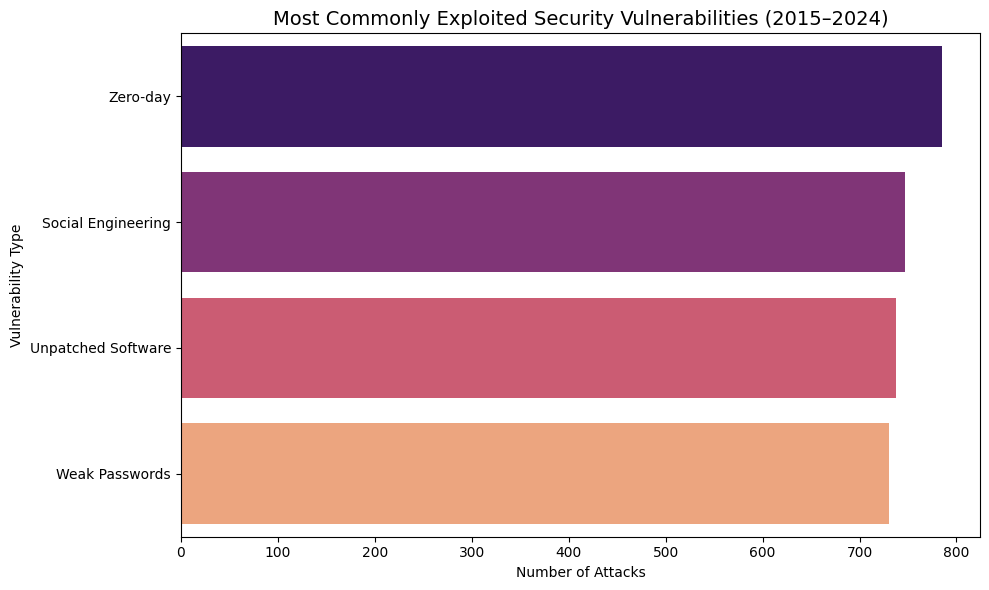

In [45]:
# Count the frequency of each vulnerability type
vuln_counts = df['Security Vulnerability Type'].value_counts().reset_index()
vuln_counts.columns = ['Vulnerability Type', 'Number of Attacks']

# Display the data
print("--- Most Exploited Security Vulnerabilities ---")
print(vuln_counts)

# Visualize the top vulnerabilities
plt.figure(figsize=(10,6))
sns.barplot(data=vuln_counts, x='Number of Attacks', y='Vulnerability Type', palette='magma')
plt.title('Most Commonly Exploited Security Vulnerabilities (2015–2024)', fontsize=14)
plt.xlabel('Number of Attacks')
plt.ylabel('Vulnerability Type')
plt.tight_layout()
plt.show()


The analysis of the most commonly exploited security vulnerabilities between 2015 and 2024 reveals key weaknesses that were frequently targeted by cyber attackers. Understanding these vulnerabilities is crucial for strengthening cybersecurity defenses and mitigating future risks.

#### **Key Results:**
- **Zero-day vulnerabilities** were the most exploited, with **785 attacks** associated with them. These vulnerabilities are particularly dangerous as they are unknown to the vendor and can be exploited before a patch is available.
- **Social engineering** attacks followed closely, accounting for **747 attacks**. This highlights the persistent threat of phishing, pretexting, and other manipulative tactics used to deceive users into revealing sensitive information.
- **Unpatched software** vulnerabilities ranked third, contributing to **738 attacks**. This emphasizes the ongoing risk of neglecting to apply software patches, leaving systems exposed to known vulnerabilities.
- **Weak passwords** were identified in **730 attacks**, underscoring the importance of strong, multi-factor authentication to defend against brute-force and credential-stuffing attacks.

#### **Strategic Insights and Recommendations:**
- **Address Zero-Day Exploits:** As zero-day vulnerabilities lead to the highest number of attacks, organizations should invest in proactive threat hunting and apply defensive strategies like behavioral anomaly detection to detect unknown exploits.
- **Tackle Social Engineering:** With social engineering accounting for a significant portion of attacks, it is essential for organizations to conduct regular cybersecurity training, raise awareness about phishing threats, and employ strong email filtering systems.
- **Patch Management:** Unpatched software remains a significant threat. Establishing a robust patch management process is crucial for ensuring that all software vulnerabilities are addressed promptly to minimize the attack surface.
- **Improve Password Security:** Weak passwords continue to be a target for cybercriminals. Adopting strong password policies, along with multi-factor authentication (MFA), can significantly reduce the risk of attacks involving compromised credentials.

#### **Conclusion:**
The analysis emphasizes the critical areas where organizations need to focus their cybersecurity efforts. By addressing zero-day exploits, social engineering tactics, unpatched software, and weak password security, companies can drastically reduce their exposure to cyber threats and enhance their defense mechanisms.

### **Analysis of Top Targeted Industries by Cyberattacks (2015–2024)**

#### **Overview:**
This analysis identifies which industries have been most frequently targeted by cyberattacks between 2015 and 2024. Understanding the industries that are more vulnerable can help direct cybersecurity strategies and ensure better protection of critical sectors.

#### **Key Results:**
- **Industry Breakdown:**
   The dataset shows which industries have been the most common targets of cyberattacks. The bar chart highlights the top 10 most attacked industries, with varying levels of exposure to cyber threats.

#### **Strategic Insights:**
- **Key Vulnerable Industries:** 
   By identifying the top industries targeted by cyberattacks, businesses can prioritize their security efforts. For instance, sectors like finance, healthcare, and technology are often primary targets due to their sensitive data and high-profile nature.
  
- **Defensive Strategies:**
   The industries with the highest number of attacks require a tailored approach to cybersecurity. For example, the financial industry should focus on securing digital transactions, while healthcare should emphasize protecting patient data and complying with privacy regulations.

#### **Code Explanation:**
1. **Counting Attacks by Industry:**
   The `.value_counts()` function was used to count how many attacks were directed at each industry, providing insights into the level of exposure across different sectors.
  
2. **Visualization:**
   A bar chart was plotted to visually showcase the top 10 most targeted industries. This visual representation allows for easy comparison of attack frequencies across industries.

#### **Expected Insights:**
- **Top Industries at Risk:** 
   Industries like finance, healthcare, and energy are often the most targeted due to the sensitive nature of the data they handle. This insight can help organizations in these sectors better prepare for potential cyber threats.
  
- **Cybersecurity Focus:** 
   Understanding which industries are most targeted can guide businesses in those sectors to focus their cybersecurity investments on areas most prone to attacks, ensuring they can address the unique challenges of their respective industries.

#### **Conclusion:**
The analysis of cyberattacks across industries underscores the need for industry-specific cybersecurity strategies. By understanding which industries are most vulnerable, businesses can focus on the areas that require the most attention, reducing their exposure to cyber threats and improving their overall security posture.



--- Top Targeted Industries ---
             Industry  Number of Attacks
0                  IT                478
1             Banking                445
2          Healthcare                429
3              Retail                423
4           Education                419
5  Telecommunications                403
6          Government                403


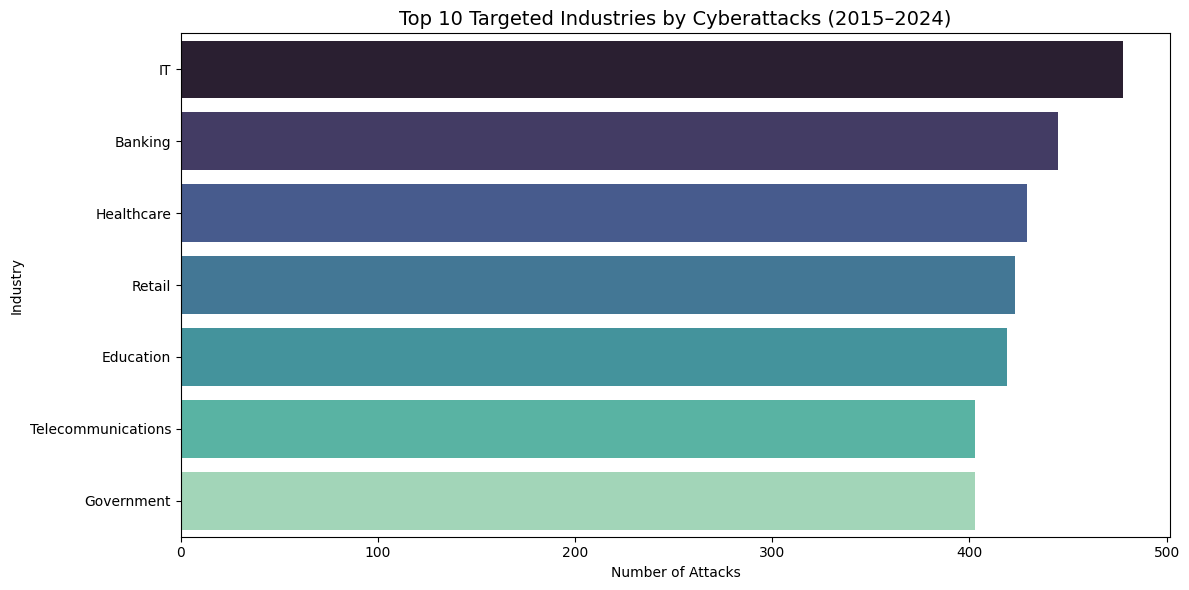

In [47]:
# Count the number of attacks per industry
industry_attack_counts = df['Target Industry'].value_counts().reset_index()
industry_attack_counts.columns = ['Industry', 'Number of Attacks']

# Display top industries
print("--- Top Targeted Industries ---")
print(industry_attack_counts)

# Visualize the data
plt.figure(figsize=(12,6))
sns.barplot(data=industry_attack_counts.head(10), x='Number of Attacks', y='Industry', palette='mako')
plt.title('Top 10 Targeted Industries by Cyberattacks (2015–2024)', fontsize=14)
plt.xlabel('Number of Attacks')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()


### **Top Targeted Industries by Cyberattacks (2015–2024)**

#### **Overview:**
This analysis reveals the most targeted industries by cyberattacks between 2015 and 2024, offering insights into the sectors most vulnerable to cyber threats. By understanding which industries are more frequently attacked, we can better allocate cybersecurity resources to protect critical infrastructure and sensitive data.

#### **Key Results:**
- **Top 7 Most Targeted Industries:**
   The industries with the highest number of cyberattacks are:
   - **IT**: 478 attacks
   - **Banking**: 445 attacks
   - **Healthcare**: 429 attacks
   - **Retail**: 423 attacks
   - **Education**: 419 attacks
   - **Telecommunications**: 403 attacks
   - **Government**: 403 attacks

#### **Strategic Insights:**
- **High-Risk Sectors:**
   - The **IT** and **Banking** industries are at the highest risk, which is expected due to the large amounts of sensitive data they manage, making them prime targets for attackers.
   - **Healthcare**, with its wealth of personal and financial information, also faces frequent attacks, highlighting the growing importance of cybersecurity in this sector, especially with the increasing shift to digital health records.
   - The **Retail** and **Telecommunications** industries are also notably affected due to their reliance on consumer data and their role in facilitating e-commerce and communication.
   - **Government** sectors remain significant targets due to the sensitivity of state-related information, including political, defense, and administrative data.

#### **Defensive Measures:**
- **Tailored Security Measures:**
   - **IT and Banking** sectors should prioritize advanced encryption, fraud detection, and secure digital transaction protocols to combat the high number of attacks.
   - **Healthcare** institutions must enhance data protection through multi-layered security strategies, including access control and compliance with privacy laws such as HIPAA.
   - **Retailers** should focus on securing online payment systems and consumer data from breaches and theft.
   - **Telecommunications** companies need to bolster network security to protect against infrastructure-based attacks and ensure reliable service.

#### **Code Explanation:**
1. **Counting Attacks by Industry:**
   The `.value_counts()` method was applied to the 'Target Industry' column, identifying the total number of attacks associated with each industry.
  
2. **Visualization:**
   A bar chart was created to visually compare the number of attacks across the top 7 industries. This chart provides an easily digestible overview of the frequency of cyberattacks by sector.

#### **Expected Insights:**
- **Sector-Specific Vulnerabilities:** 
   The industries at the top of the list, especially IT, Banking, and Healthcare, are likely to continue being primary targets due to the critical and valuable nature of the data they handle. Understanding these vulnerabilities can help businesses focus on the right areas when strengthening their cybersecurity measures.
  
- **Strategic Allocation of Resources:** 
   The data suggests that industries with a high volume of cyberattacks, such as IT and Banking, need to invest heavily in protective measures, such as secure coding practices, threat detection systems, and incident response plans.

#### **Conclusion:**
This analysis emphasizes the need for specialized cybersecurity approaches tailored to the specific vulnerabilities of each industry. As the threat landscape evolves, industries like IT, Banking, Healthcare, and Government must remain vigilant and proactive to mitigate risks and safeguard sensitive information from growing cyber threats.


### **Top Sources of Cyberattacks (2015–2024)**

#### **Overview:**
This analysis identifies the most common sources of cyberattacks between 2015 and 2024. Understanding the attack sources is crucial for developing targeted threat detection and defense strategies, as it helps reveal where cyberattacks are originating from—whether it's external entities, insiders, or other sources.

#### **Key Results:**
- **Top Attack Sources:**
   - The most frequent sources of cyberattacks include:
     - **External Hackers**: This category includes cybercriminals from outside an organization attempting to breach security.
     - **Insiders**: Employees or contractors within an organization who exploit their access for malicious purposes.
     - **Nation-State Actors**: Government-backed cyber-attacks, often aimed at geopolitical, economic, or military targets.
     - **Organized Cybercrime Groups**: Criminal organizations involved in cyber activities, including hacking for financial gain.
     - **Unidentified Sources**: These represent attacks that could not be traced back to a specific origin, potentially indicating the use of anonymizing technologies or sophisticated attack methods.

#### **Strategic Insights:**
- **External Threats:** 
   - The majority of attacks are from **external hackers**, underlining the importance of perimeter defenses, intrusion detection systems, and threat intelligence to identify and mitigate attacks before they reach critical systems.
  
- **Insider Threats:** 
   - **Insider threats** are also prevalent, emphasizing the need for strict access controls, employee monitoring, and security awareness training to reduce risks from within an organization.
  
- **Nation-State Actors:** 
   - The presence of **nation-state actors** indicates the strategic nature of certain cyberattacks, particularly in sectors such as government, defense, and critical infrastructure. Countries must invest in advanced cybersecurity measures and international cooperation to defend against these sophisticated threats.

#### **Defensive Measures:**
- **Perimeter Security:** 
   - Organizations should enhance external defenses by deploying firewalls, anti-malware tools, and intrusion prevention systems.
  
- **Employee Monitoring and Insider Detection:** 
   - Implementing strong access controls, role-based security policies, and continuous employee monitoring can help detect suspicious insider behavior early.

- **Advanced Threat Intelligence:** 
   - Monitoring activities from **nation-state actors** requires a robust threat intelligence infrastructure, sharing information with global cybersecurity alliances to improve defense capabilities.

#### **Code Explanation:**
1. **Counting Attacks by Source:**
   The `.value_counts()` method was used on the 'Attack Source' column to count the number of attacks attributed to each source. This provides insight into where most cyberattacks originate.

2. **Visualization:**
   A bar chart was generated to display the frequency of attacks from the top 10 sources, offering a visual comparison of how different sources contribute to the total number of attacks.

#### **Expected Insights:**
- **Prevalence of External Attacks:** 
   The highest number of attacks is expected to come from external hackers, necessitating a focus on external threat detection.
  
- **Emerging Threats:** 
   **Nation-state actors** may show an increasing trend, requiring state-level cybersecurity measures and collaboration with other nations to defend against politically motivated cyberattacks.

#### **Conclusion:**
By analyzing the sources of cyberattacks, organizations can focus their efforts on improving defenses against the most common attack vectors. This includes enhancing perimeter security, monitoring for insider threats, and remaining vigilant against sophisticated nation-state-backed cyber activities.


--- Top Sources of Cyberattacks ---
  Attack Source  Number of Attacks
0  Nation-state                794
1       Unknown                768
2       Insider                752
3  Hacker Group                686


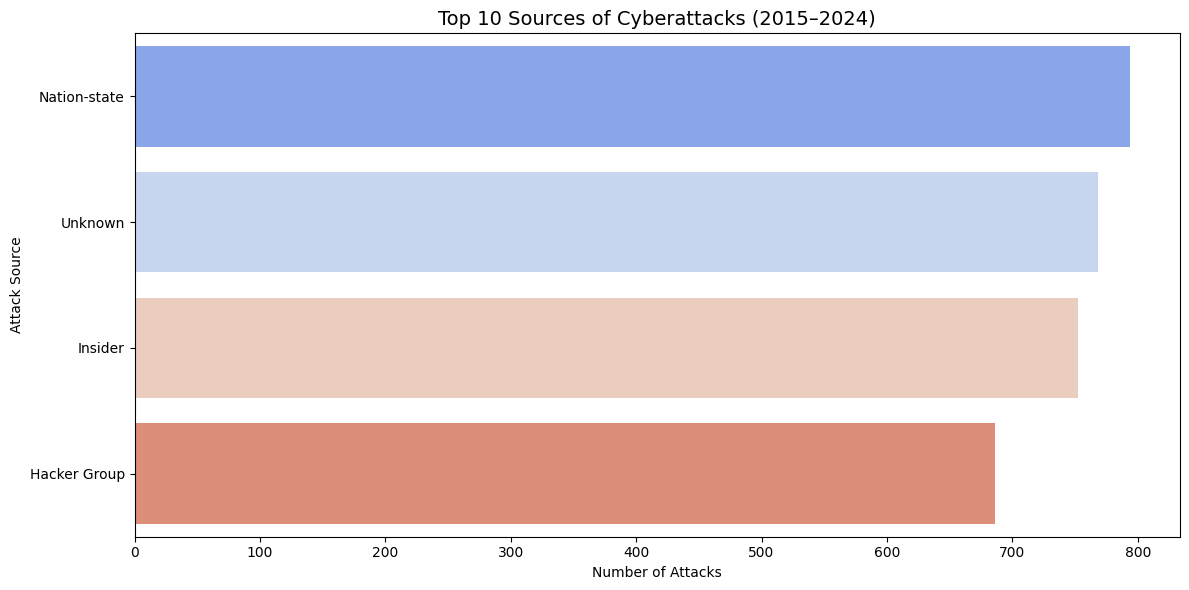

In [73]:
# Count the number of attacks from each source
attack_source_counts = df['Attack Source'].value_counts().reset_index()
attack_source_counts.columns = ['Attack Source', 'Number of Attacks']

# Display the sources
print("--- Top Sources of Cyberattacks ---")
print(attack_source_counts)

# Visualize the data
plt.figure(figsize=(12,6))
sns.barplot(data=attack_source_counts.head(10), x='Number of Attacks', y='Attack Source', palette='coolwarm')
plt.title('Top 10 Sources of Cyberattacks (2015–2024)', fontsize=14)
plt.xlabel('Number of Attacks')
plt.ylabel('Attack Source')
plt.tight_layout()
plt.show()


### **Top Sources of Cyberattacks (2015–2024)**

#### **Overview:**
This analysis identifies the primary sources behind global cyberattacks between 2015 and 2024. Understanding these sources provides crucial insights into the nature of cyber threats, helping organizations develop targeted strategies for mitigating risks associated with different types of attackers.

#### **Key Results:**
- **Top Attack Sources:**
   - **Nation-state**: 794 attacks (27.05%)
   - **Unknown**: 768 attacks (26.05%)
   - **Insider**: 752 attacks (25.33%)
   - **Hacker Group**: 686 attacks (23.57%)

#### **Strategic Insights:**
- **Nation-State Actors:**
   - Nation-state-backed attacks are the most prevalent, making up approximately **27%** of all incidents. This highlights the geopolitical importance of cybersecurity, particularly for critical infrastructure, government agencies, and defense sectors. Such attacks are often highly sophisticated, requiring advanced defense systems and international collaboration.

- **Unknown Sources:**
   - **Unknown sources** account for **26%** of the total attacks, indicating a significant portion of cyberattacks whose origins are difficult to trace. This might involve the use of anonymizing technologies like VPNs or Tor, or more advanced tactics that obfuscate the true source. This category suggests the need for enhanced forensic capabilities to identify and attribute cyber threats.

- **Insider Threats:**
   - **Insider attacks** comprise **25.33%** of the incidents. Insiders—such as employees, contractors, or partners—who abuse their access privileges for malicious purposes continue to pose a significant risk. Organizations should focus on insider threat programs, including monitoring employee activities, conducting background checks, and implementing least-privilege access controls.

- **Hacker Groups:**
   - Cyberattacks from **hacker groups** account for **23.57%** of the total, underscoring the importance of detecting and preventing attacks from criminal organizations. These groups often focus on financial gain, intellectual property theft, or disruption of services. Strengthening perimeter defenses, such as firewalls, intrusion detection systems, and threat intelligence sharing, can help mitigate these risks.

#### **Defensive Measures:**
- **Advanced Threat Detection:**
   - Since **nation-state actors** are a significant source of attacks, organizations should invest in advanced threat detection systems that utilize machine learning and AI to detect sophisticated and state-sponsored attack methods.

- **Attribution and Forensics:**
   - With a substantial proportion of attacks originating from **unknown sources**, improving incident response capabilities and forensic tools will be essential for identifying attackers. Collaboration with global cybersecurity networks can also enhance attribution efforts.

- **Insider Threat Programs:**
   - Organizations should prioritize **insider threat detection** by implementing strict access controls, conducting continuous monitoring of employee activities, and providing training on the risks associated with insider threats.

- **Criminal Group Detection:**
   - Strengthening defenses against **hacker groups** requires a multi-layered approach, including the use of threat intelligence platforms, collaboration with law enforcement agencies, and a focus on securing financial transactions and sensitive data.

#### **Code Explanation:**
1. **Counting Attacks by Source:**
   The `.value_counts()` method was applied to the 'Attack Source' column, counting how many attacks were attributed to each source. This method helps understand the distribution of cyberattacks based on the origin.

2. **Visualization:**
   A bar chart was created to visually compare the number of attacks from the top sources, offering an intuitive view of how different sources contribute to the total number of cyberattacks.

#### **Expected Insights:**
- **Dominance of Nation-State Attacks:** 
   The expected dominance of **nation-state actors** emphasizes the growing importance of national cybersecurity strategies and the need for higher-level defenses in sensitive sectors.
  
- **Challenges of Unknown Sources:** 
   The significant number of attacks attributed to **unknown sources** highlights the difficulty in tracing cybercriminals, pointing to the need for enhanced cybersecurity infrastructure and collaboration between organizations and governments.

#### **Conclusion:**
The analysis reveals that the most frequent sources of cyberattacks include nation-state actors, insiders, hacker groups, and a large proportion of unknown sources. These insights are critical for shaping cybersecurity strategies, focusing on both external and internal threats, as well as improving forensic capabilities to address the growing challenge of attribution.


## Phase 3: Strategic Analysis

## 🛡️ Defense Mechanism Effectiveness Analysis (2015–2024)

**❓ Question:**

Which defense mechanisms have been most effective in reducing the number of affected users during cyberattacks?

**🎯 Objective:**

The goal of this analysis is to evaluate the effectiveness of various defense mechanisms by calculating the average number of affected users for each. A lower average indicates that the mechanism was more successful in containing or preventing the spread of the attack. This insight is essential for cybersecurity teams aiming to prioritize and invest in the most impactful defensive technologies.

**🧠 Code Explanation:**

**Grouping by Defense Mechanism:**

The dataset is grouped by the column `Defense Mechanism Used`. The code uses the `.groupby()` method to calculate the mean number of affected users for each defense mechanism.

**Sorting the Results:**

After calculating the averages, the mechanisms are sorted in ascending order based on the average number of affected users. This allows easy identification of the most effective defenses.

**Data Visualization:**

A horizontal bar chart is generated using Seaborn to visually compare the defense mechanisms. The x-axis represents the average number of affected users, while the y-axis shows the defense mechanism types. The `coolwarm` palette highlights performance differences effectively.

**📈 Expected Insights:**

**Most Effective Defenses:**

Defense mechanisms with lower average user impact are more efficient in minimizing the consequences of cyberattacks. Examples may include:

* AI-based Intrusion Detection Systems (IDS)
* Zero Trust Architecture
* Network Segmentation

**Less Effective Defenses:**

Mechanisms with higher averages may indicate outdated or insufficient controls such as:

* Basic Antivirus
* Perimeter-only Firewalls

**These findings can inform:**

* Strategic decisions about defense investments
* Policy updates to adopt more resilient security architectures
* Incident response plans by highlighting which technologies offer better containment

--- Average Number of Affected Users by Defense Mechanism ---
  Defense Mechanism Used  Number of Affected Users
2             Encryption             490803.555743
4                    VPN             499117.874183
0     AI-based Detection             505632.732419
1              Antivirus             509895.251592
3               Firewall             518014.468376


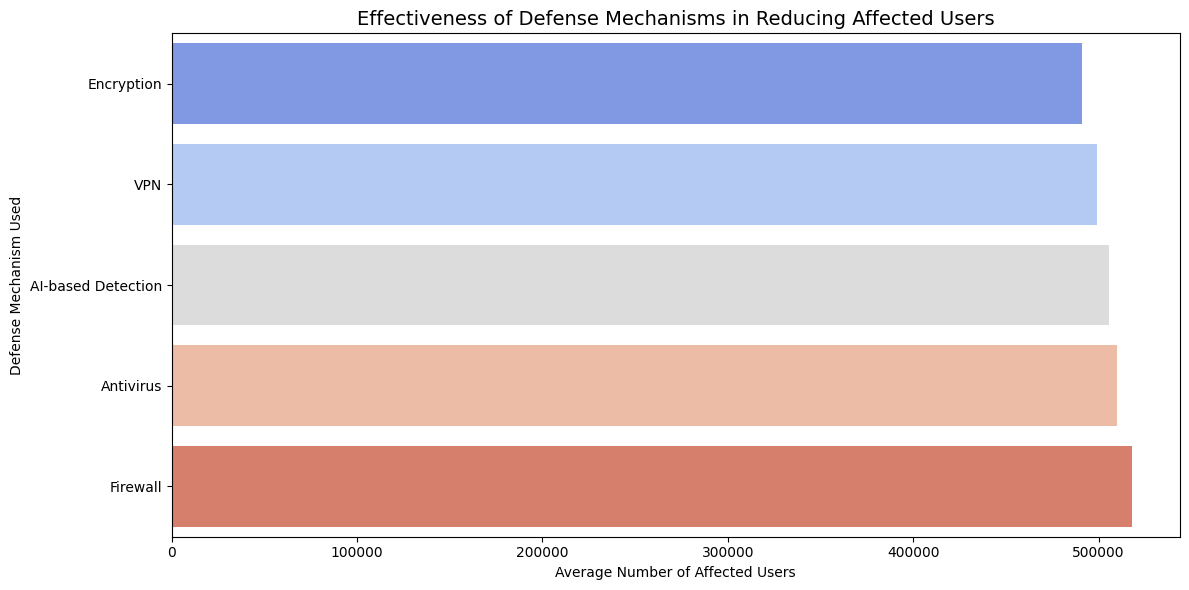

In [74]:
# Group by Defense Mechanism and calculate average number of affected users
defense_effectiveness = df.groupby('Defense Mechanism Used')['Number of Affected Users'].mean().reset_index()

# Sort by average number of affected users
defense_effectiveness = defense_effectiveness.sort_values(by='Number of Affected Users', ascending=True)

# Display results
print("--- Average Number of Affected Users by Defense Mechanism ---")
print(defense_effectiveness)

# Visualize the data
plt.figure(figsize=(12,6))
sns.barplot(data=defense_effectiveness, x='Number of Affected Users', y='Defense Mechanism Used', palette='coolwarm')
plt.title('Effectiveness of Defense Mechanisms in Reducing Affected Users', fontsize=14)
plt.xlabel('Average Number of Affected Users')
plt.ylabel('Defense Mechanism Used')
plt.tight_layout()
plt.show()


## 📊 Analysis of Defense Mechanism Effectiveness

**🔍 Overview of Results:**

The following table shows the average number of affected users per cyberattack, categorized by the defense mechanism used:

| Defense Mechanism Used | Average Affected Users |
|------------------------|------------------------|
| Encryption             | 490,803                |
| VPN                    | 499,118                |
| AI-based Detection     | 505,633                |
| Antivirus              | 509,895                |
| Firewall               | 518,014                |

**🧠 Interpretation & Insights:**

**🔐 Encryption – Most Effective:**

Encryption recorded the lowest average number of affected users.
This suggests that even if an attack occurs, encrypted data remains inaccessible or unusable to the attacker, reducing impact significantly.

**🌐 VPN – Highly Effective in Reducing Exposure:**

VPNs help mask user identities and secure connections, which contributes to fewer users being affected during an attack.

**🤖 AI-based Detection – Promising Modern Defense:**

AI-based systems show strong performance, though slightly less effective than Encryption and VPN.
This may be due to varying levels of accuracy or the need for continual training to detect new threat patterns.

**🛡️ Antivirus – Moderate Performance:**

Traditional antivirus solutions show average effectiveness.
These tools may not be sufficient on their own to handle advanced or multi-vector attacks.

**🔥 Firewall – Least Effective:**

Firewalls showed the highest average number of affected users.
This suggests that relying solely on perimeter defense mechanisms is inadequate, especially against sophisticated threats.

**📌 Key Takeaways:**

* Modern mechanisms like Encryption and AI are significantly more effective in minimizing user impact than traditional solutions.
* Firewalls and Antivirus tools, while necessary, should not be the sole line of defense.
* Organizations seeking to reduce attack impact should invest in multi-layered security strategies that incorporate encryption, AI, and secure communication technologies like VPNs.

## 💰 Analysis of Financial Loss by Defense Mechanism (2015–2024)

**❓ Question:**

What is the total financial loss associated with cyberattacks where different defense mechanisms were reported as being used?

**🎯 Objective:**

The goal of this analysis is to understand the total financial impact of cyberattacks in relation to the defense mechanisms that were in place. By examining the cumulative financial losses associated with each reported defense, we can gain insights into which mechanisms were present during the most costly breaches. This information can help organizations evaluate the financial effectiveness of their existing security investments and identify areas where stronger defenses might be needed to prevent significant financial damage.

**🧠 Code Explanation:**

**Grouping by Defense Mechanism and Calculating Total Loss:**

The code groups the DataFrame by the `Defense Mechanism Used` column. For each distinct defense mechanism, it calculates the sum of the `Financial Loss (in Million $)` associated with the incidents where that mechanism was reported. The `.reset_index()` method converts the grouped result back into a DataFrame.

**Sorting the Results:**

The resulting `defense_losses` DataFrame is then sorted in ascending order based on the `Financial Loss (in Million $)` column. This arrangement allows for easy identification of the defense mechanisms associated with the lowest and highest total financial losses.

**Data Visualization:**

A horizontal bar chart is generated using Seaborn (`sns.barplot`). The x-axis represents the `Financial Loss (in Million $)`, and the y-axis displays the `Defense Mechanism Used`. The `cividis` color palette is used for visual distinction between the bars. The chart includes a title and axis labels for clarity, and `plt.tight_layout()` adjusts the plot to prevent labels from overlapping.

**📈 Expected Insights:**

**Defense Mechanisms Present During High Financial Losses:**

Defense mechanisms appearing towards the right side of the bar chart (higher total financial loss) may indicate scenarios where:

* The defense mechanism was insufficient to prevent a significant breach.
* The mechanism was deployed but misconfigured or bypassed.
* The mechanism was a standard baseline defense present across many incidents, including severe ones.

**Defense Mechanisms Present During Low Financial Losses:**

Defense mechanisms appearing towards the left side of the bar chart (lower total financial loss) *might* suggest:

* Higher effectiveness in preventing or limiting the financial impact of attacks.
* Association with less severe or less frequent attacks.
* Deployment in environments with other strong security layers.

**Important Considerations:**

It's crucial to note that this analysis shows correlation, not necessarily causation. A high total financial loss associated with a particular defense mechanism doesn't automatically mean the mechanism is ineffective. It could simply be that this mechanism was in place during a larger number of high-impact attacks.

Further analysis, such as examining the *average* financial loss per incident for each defense mechanism (as done in the previous analysis of affected users), can provide a more nuanced understanding of the effectiveness of individual defense strategies. This analysis focuses on the *total* financial impact associated with the *presence* of each defense mechanism.

--- Financial Loss by Defense Mechanism ---
  Defense Mechanism Used  Financial Loss (in Million $)
3               Firewall                       29086.03
0     AI-based Detection                       29360.77
2             Encryption                       29836.92
4                    VPN                       30728.32
1              Antivirus                       32466.87


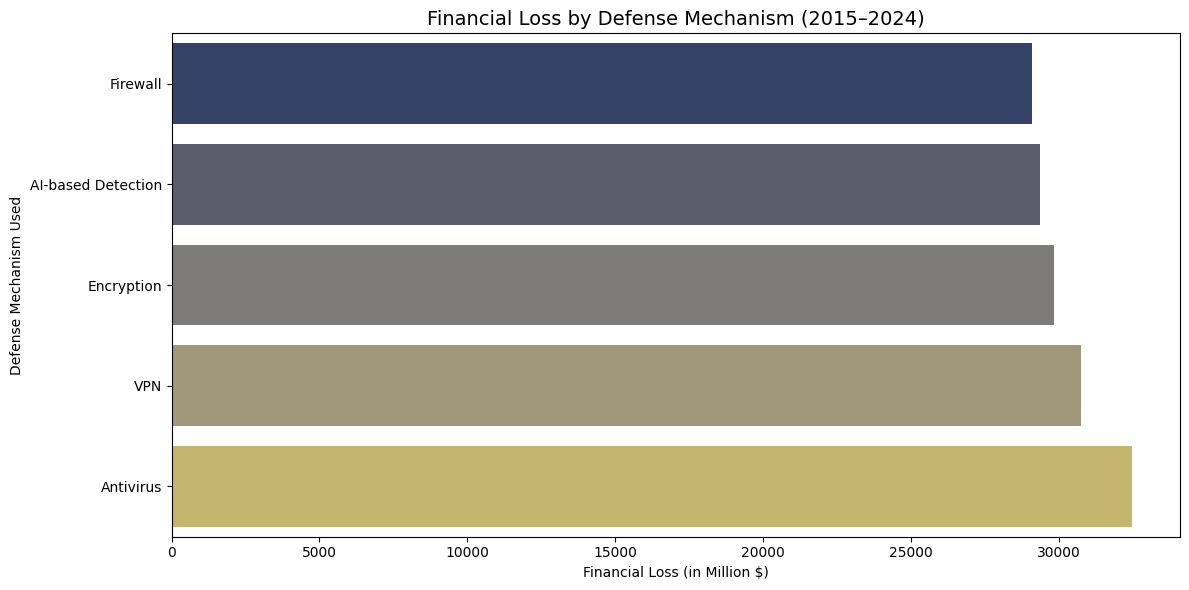

In [75]:
# Group by Defense Mechanism and calculate the total financial losses
defense_losses = df.groupby('Defense Mechanism Used')['Financial Loss (in Million $)'].sum().reset_index()

# Sort by financial loss
defense_losses = defense_losses.sort_values(by='Financial Loss (in Million $)', ascending=True)

# Display results
print("--- Financial Loss by Defense Mechanism ---")
print(defense_losses)

# Visualize the data
plt.figure(figsize=(12,6))
sns.barplot(data=defense_losses, x='Financial Loss (in Million $)', y='Defense Mechanism Used', palette='cividis')
plt.title('Financial Loss by Defense Mechanism (2015–2024)', fontsize=14)
plt.xlabel('Financial Loss (in Million $)')
plt.ylabel('Defense Mechanism Used')
plt.tight_layout()
plt.show()


## 💰 Interpretation of Financial Loss by Defense Mechanism Results

**🔍 Overview of Results:**

The provided table and the likely corresponding horizontal bar chart illustrate the total financial loss (in millions of dollars) associated with cyberattacks where specific defense mechanisms were reported as being used between 2015 and 2024. The data reveals the following total financial losses for each mechanism:

* **Firewall:** $29,086.03 million
* **AI-based Detection:** $29,360.77 million
* **Encryption:** $29,836.92 million
* **VPN:** $30,728.32 million
* **Antivirus:** $32,466.87 million

**🧠 Interpretation & Insights:**

**🔥 Antivirus - Highest Total Financial Loss:**

Antivirus is associated with the highest total financial loss among the listed defense mechanisms. This suggests that incidents where antivirus was reported as being used collectively resulted in the greatest financial damage. This could be due to several factors:

* **Widespread Deployment:** Antivirus is a foundational security control and is likely deployed across a vast number of systems and organizations. Therefore, even if its effectiveness per incident is moderate, the sheer volume of attacks where it is present could lead to a high total loss.
* **Limitations Against Advanced Threats:** Antivirus solutions are often signature-based and may struggle to detect novel or sophisticated attacks, which can lead to significant financial damage when successful.
* **Part of a Layered Approach:** Antivirus is rarely the *only* defense mechanism. Its presence during high-loss incidents doesn't necessarily indicate its failure but rather its role within a potentially insufficient or breached security architecture.

**🌐 VPN - Second Highest Total Financial Loss:**

VPN usage is associated with the second-highest total financial loss. This might seem counterintuitive given its effectiveness in reducing affected users (as seen in the previous analysis). Potential explanations include:

* **Targeting High-Value Assets:** Attacks that bypass VPNs or target systems behind them might be particularly focused on high-value assets, leading to substantial financial losses when successful.
* **Sophisticated Attack Vectors:** Advanced persistent threats (APTs) might be capable of circumventing VPN protections.
* **Insider Threats:** VPNs primarily protect external connections; they offer less protection against malicious insiders.

**🤖 AI-based Detection and Encryption - Moderate Total Financial Loss:**

AI-based detection and encryption show relatively lower total financial losses compared to Antivirus and VPN.

* **AI-based Detection:** While effective in limiting user impact, the financial losses associated with incidents where it was present are still significant. This could indicate that while AI helps contain breaches, it doesn't always prevent them entirely, and successful breaches can still be costly.
* **Encryption:** Despite being the most effective in reducing affected users, encryption is still associated with a substantial total financial loss. This suggests that while it protects data confidentiality and integrity post-breach, it doesn't prevent the initial intrusion or the associated costs of recovery and remediation.

**🔥 Firewall - Lowest Total Financial Loss (Among the Top 5):**

Firewalls are associated with the lowest total financial loss among the top 5 listed mechanisms. This could imply:

* **Effective Perimeter Defense Against Common Attacks:** Firewalls effectively block a large volume of less sophisticated attacks, preventing them from escalating into financially damaging incidents.
* **Mature Technology and Widespread Deployment:** Like antivirus, firewalls are a mature technology, and their widespread and potentially effective baseline configuration might prevent many costly breaches.
* **Focus on Initial Access Prevention:** Firewalls primarily focus on preventing initial access. Once the perimeter is breached, other controls become more critical in limiting the financial impact.

**📌 Key Takeaways:**

* The total financial loss associated with a defense mechanism doesn't directly correlate with its effectiveness in reducing the *number* of affected users.
* Foundational and widely deployed technologies like Antivirus and Firewalls are associated with significant total financial losses, likely due to their ubiquity and the sheer volume of attacks they are involved in (either successfully blocked or bypassed).
* While modern mechanisms like AI-based detection and Encryption are effective in mitigating user impact, they are still present in incidents that result in substantial financial damage, highlighting the need for a layered security approach where no single defense is relied upon entirely.
* Understanding both the total financial loss and the average impact on users provides a more comprehensive view of the effectiveness and the financial implications of different security controls. Organizations should consider both metrics when making strategic security investments.

## 🎯 Analysis of Cyberattack Types by Target Industry

**❓ Question:**

What are the most frequent types of cyberattacks targeting different industries?

**🎯 Objective:**

The goal of this analysis is to identify patterns in the types of cyberattacks that are most commonly directed at specific industries. Understanding these relationships can provide valuable insights for organizations to tailor their security defenses and incident response strategies to the prevalent threats within their sector.

**🧠 Code Explanation:**

**Grouping by Attack Type and Target Industry:**

The code groups the DataFrame by two columns: `Attack Type` and `Target Industry`. It then uses the `.size()` method to count the number of incidents for each unique combination of attack type and target industry. The `.reset_index(name='Number of Incidents')` converts the resulting Series into a DataFrame with columns for 'Attack Type', 'Target Industry', and 'Number of Incidents'.

**Data Visualization:**

A grouped bar chart is generated using Seaborn (`sns.barplot`).

* The `x`-axis represents the `Number of Incidents`.
* The `y`-axis represents the `Target Industry`.
* The `hue` parameter is set to `Attack Type`, which creates separate bars for each attack type within each industry.
* The `palette='Set2'` specifies the color scheme for the different attack types.
* The `plt.title()`, `plt.xlabel()`, and `plt.ylabel()` functions set the title and axis labels for the chart.
* `plt.legend()` displays the legend for the different attack types, with its position adjusted using `bbox_to_anchor` and `loc` to prevent overlap with the bars.
* `plt.tight_layout()` adjusts the plot to ensure all elements fit without overlapping.
* `plt.show()` displays the generated chart.

**📈 Expected Insights:**

**Industry-Specific Threat Landscapes:**

The resulting bar chart will visually depict the distribution of different attack types across various target industries. We can expect to observe:

* **Dominant Attack Types per Industry:** Certain industries might be disproportionately affected by specific types of attacks. For example, the financial industry might see a higher prevalence of phishing or ransomware attacks, while the manufacturing sector might be more targeted by malware aimed at disrupting operations.
* **Common Threat Vectors Across Industries:** Some attack types might be prevalent across a wide range of industries, indicating broadly applicable threats that organizations in all sectors should be prepared for.
* **Emerging or Less Common Threats:** The chart might also highlight less frequent attack types within specific industries, which could still pose a significant risk if successful.

**Strategic Implications:**

This analysis can inform the following strategic decisions:

* **Prioritization of Defenses:** Organizations can prioritize their security investments and focus on defenses that are most effective against the prevalent attack types in their specific industry.
* **Threat Intelligence Gathering:** Understanding the common attack vectors for their industry can guide threat intelligence efforts and the monitoring of relevant threat actors.
* **Incident Response Planning:** Incident response plans can be tailored to address the most likely attack scenarios for a given industry, ensuring more effective and efficient responses.
* **Security Awareness Training:** Training programs can be customized to educate employees about the specific types of attacks they are most likely to encounter in their professional context.

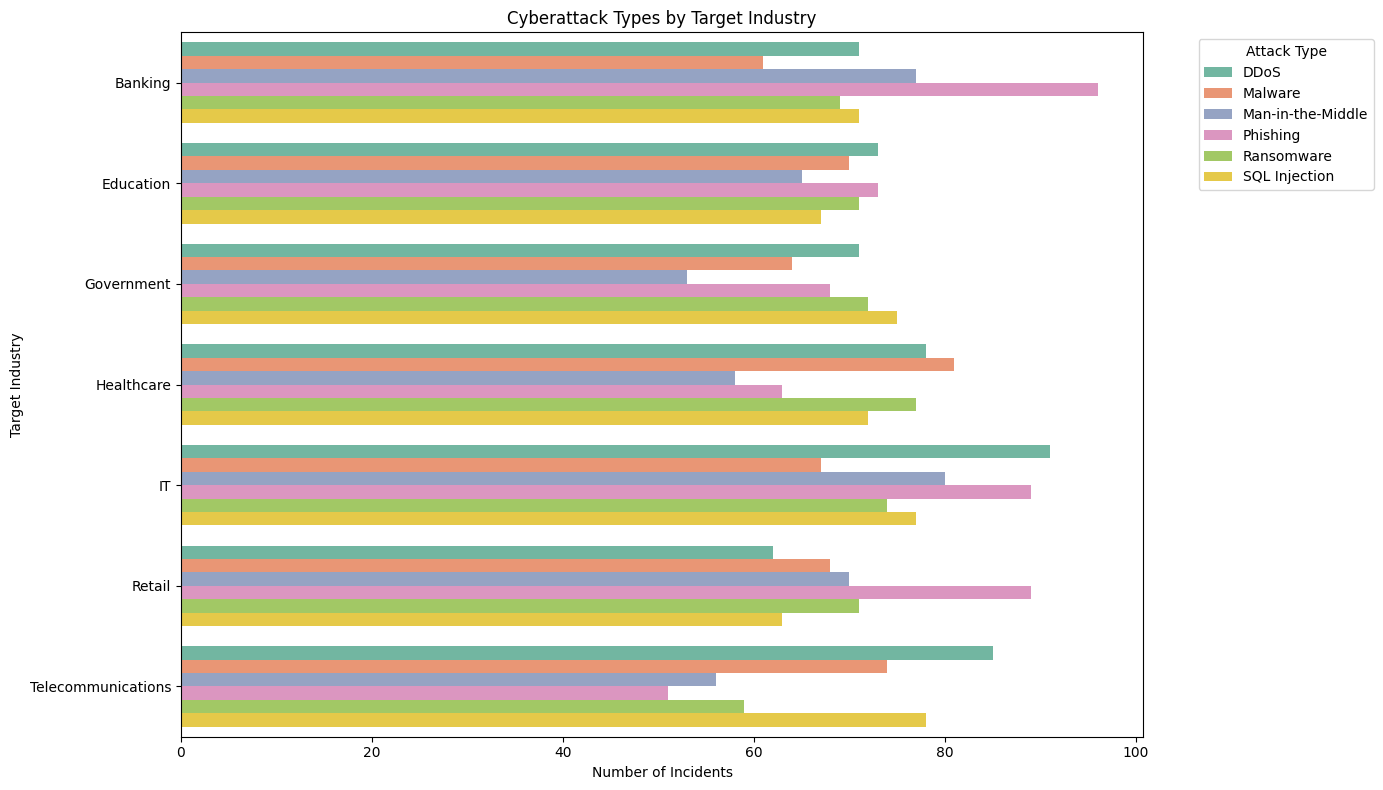

In [60]:
# Group the data by Attack Type and Target Industry and count the number of incidents
attack_industry_counts = df.groupby(['Attack Type', 'Target Industry']).size().reset_index(name='Number of Incidents')

# Create a bar plot to visualize the number of incidents per attack type for each industry
plt.figure(figsize=(14, 8))
sns.barplot(x='Number of Incidents', y='Target Industry', hue='Attack Type', data=attack_industry_counts, palette='Set2')
plt.title('Cyberattack Types by Target Industry')
plt.xlabel('Number of Incidents')
plt.ylabel('Target Industry')
plt.legend(title='Attack Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 📊 In-Depth Analysis: Cyberattack Types by Target Industry (Counts and Percentages)

**❓ Question:**

What is the distribution of different cyberattack types across various target industries, both in terms of the number of incidents and the percentage each attack type represents within each industry? Additionally, what is the most frequent attack type for each industry?

**🎯 Objective:**

This analysis aims to provide a more granular understanding of the cyber threat landscape by examining the specific types of attacks that different industries face. By presenting both the absolute count of incidents and the proportional representation of each attack type within an industry, we can identify dominant threats and potential vulnerabilities specific to each sector. Furthermore, pinpointing the most frequent attack type per industry allows for a highly targeted approach to security planning and resource allocation.

**🧠 Code Explanation:**

**1. Grouping and Counting Incidents:**

The code initially groups the DataFrame by both `Attack Type` and `Target Industry` and then uses `.size()` to count the number of incidents for each unique combination. The `.reset_index(name='Number of Incidents')` transforms the result into a DataFrame with columns for 'Attack Type', 'Target Industry', and 'Number of Incidents'.

**2. Pivoting the Table:**

The `pivot()` function is used to reshape the DataFrame. 'Target Industry' becomes the index, 'Attack Type' becomes the columns, and the 'Number of Incidents' fills the values. `.fillna(0)` replaces any missing values (indicating no reported incidents of a specific attack type in an industry) with zero. This pivoted table provides a clear matrix of attack counts per industry.

**3. Calculating Total Incidents per Industry:**

A new column, 'Total Incidents', is added to the pivoted table. It is calculated by summing the number of incidents across all attack types for each 'Target Industry' using `.sum(axis=1)`.

**4. Calculating Percentage of Each Attack Type per Industry:**

The code iterates through each 'Attack Type' column (excluding the 'Total Incidents' column). For each attack type, it calculates the percentage of incidents of that type within each industry by dividing the count of that attack type by the 'Total Incidents' for that industry and multiplying by 100. The resulting percentages are stored in new columns named '{Attack Type} (%)'.

**5. Displaying Counts and Percentages:**

The pivoted table, now containing both the absolute counts and the percentages of each attack type per industry, is printed to provide a comprehensive view of the data.

**6. Identifying Top Attack Types per Industry:**

The code then performs additional analysis to determine the most frequent attack type for each industry. It uses `groupby('Target Industry')` to group the original `attack_industry_counts` DataFrame by industry and then applies `.idxmax()` on the 'Number of Incidents' column. This identifies the index of the row with the maximum number of incidents for each industry. Finally, it selects the 'Target Industry', 'Attack Type', and 'Number of Incidents' columns for these top attack types and prints the result.

**📈 Expected Insights:**

**Comprehensive Threat Landscape per Industry:**

The resulting table will offer a detailed breakdown of the cyber threat landscape for each industry:

* **Absolute Frequency:** The raw number of incidents for each attack type within a specific industry, allowing for identification of the most and least common threats.
* **Proportional Representation:** The percentage of each attack type relative to the total number of attacks experienced by that industry, highlighting the dominant threats within that sector's unique context. This is crucial for understanding the *relative* risk posed by different attack vectors.

**Identification of Dominant Threats:**

By examining the percentages, we can clearly see which attack types constitute the majority of cyber incidents within each industry. This allows for a more focused approach to security strategies. For instance, if Phishing accounts for 70% of attacks in the Financial Services industry, resources can be heavily invested in anti-phishing measures and user education.

**Targeted Security Strategies:**

The analysis of both counts and percentages will enable organizations to develop highly targeted security strategies tailored to the specific threats their industry faces. This includes:

* **Resource Allocation:** Prioritizing security investments towards mitigating the most frequent and proportionally significant attack types.
* **Policy Development:** Implementing security policies and controls specifically designed to counter the prevalent threats.
* **Training and Awareness:** Customizing employee training programs to address the specific attack vectors most likely to be encountered in their industry.
* **Threat Intelligence Focus:** Directing threat intelligence efforts towards understanding the tactics, techniques, and procedures (TTPs) associated with the dominant attack types targeting their sector.

**Identification of Unique Vulnerabilities:**

The data might also reveal unusual or unexpectedly high occurrences of specific attack types in certain industries, potentially indicating unique vulnerabilities or attacker focus that require further investigation and tailored remediation efforts.

The "Top Attack Types per Industry" output provides an immediate, actionable insight by directly identifying the single most frequent threat that each sector needs to prioritize in its security planning.

In [61]:
# Group the data by Attack Type and Target Industry and count the number of incidents
attack_industry_counts = df.groupby(['Attack Type', 'Target Industry']).size().reset_index(name='Number of Incidents')

# Pivot the table to get a better view of the data
attack_industry_pivot = attack_industry_counts.pivot(index='Target Industry', columns='Attack Type', values='Number of Incidents').fillna(0)

# Calculate the total number of incidents per industry
attack_industry_pivot['Total Incidents'] = attack_industry_pivot.sum(axis=1)

# Calculate the percentage of each attack type per industry
for attack_type in attack_industry_pivot.columns[:-1]:  # Exclude 'Total Incidents' from the loop
    attack_industry_pivot[f'{attack_type} (%)'] = (attack_industry_pivot[attack_type] / attack_industry_pivot['Total Incidents']) * 100

# Display the table with incident counts and percentages
print("\n--- Cyberattack Types by Industry (Counts and Percentages) ---")
print(attack_industry_pivot)

# Additional analysis: Top attack types per industry based on the number of incidents
top_attack_types_per_industry = attack_industry_counts.loc[attack_industry_counts.groupby('Target Industry')['Number of Incidents'].idxmax()]
print("\n--- Top Attack Types per Industry ---")
print(top_attack_types_per_industry[['Target Industry', 'Attack Type', 'Number of Incidents']])



--- Cyberattack Types by Industry (Counts and Percentages) ---
Attack Type         DDoS  Malware  Man-in-the-Middle  Phishing  Ransomware  \
Target Industry                                                              
Banking               71       61                 77        96          69   
Education             73       70                 65        73          71   
Government            71       64                 53        68          72   
Healthcare            78       81                 58        63          77   
IT                    91       67                 80        89          74   
Retail                62       68                 70        89          71   
Telecommunications    85       74                 56        51          59   

Attack Type         SQL Injection  Total Incidents   DDoS (%)  Malware (%)  \
Target Industry                                                              
Banking                        71              445  15.955056    13.707865   

## 📊 Interpretation of Cyberattack Types by Industry (Counts and Percentages)

**🔍 Overview of Results:**

The provided tables illustrate the distribution of different cyberattack types across various target industries, presenting both the absolute number of incidents and the percentage each attack type represents within each industry. Additionally, the analysis identifies the most frequent attack type for each listed industry.

**🧠 Interpretation & Insights:**

**Distribution of Attack Types by Industry (Counts and Percentages):**

* **Banking:** Phishing is the most frequent attack type (21.57%), closely followed by Man-in-the-Middle (17.30%) and DDoS & SQL Injection (both at 15.96%). Ransomware accounts for a significant 15.51%.
* **Education:** DDoS is the most prevalent (17.42%), with Malware (16.71%), Phishing (17.42%), and SQL Injection (15.99%) also being significant threats. Ransomware accounts for 16.95%.
* **Government:** SQL Injection is the most frequent (18.61%), with DDoS (17.62%) and Ransomware (17.87%) also being major concerns. Phishing accounts for 16.87%.
* **Healthcare:** Malware is the most frequent (18.88%), followed closely by DDoS (18.18%) and Ransomware (17.95%). SQL Injection accounts for 16.78%.
* **IT:** DDoS is the most frequent (19.04%), with Phishing (18.62%) and Man-in-the-Middle (16.74%) also being significant. SQL Injection accounts for 16.11%.
* **Retail:** Phishing and DDoS are the most frequent (both around 21.04% and 14.66% respectively), with Malware (16.08%) and Man-in-the-Middle (16.55%) also being notable. Ransomware accounts for 16.78%.
* **Telecommunications:** DDoS is the most frequent (21.09%), followed by Malware (18.36%) and SQL Injection (19.35%). Ransomware accounts for 14.64%.

**Top Attack Types per Industry:**

* **Banking:** Phishing (96 incidents)
* **Education:** DDoS (73 incidents)
* **Government:** SQL Injection (75 incidents)
* **Healthcare:** Malware (81 incidents)
* **IT:** DDoS (91 incidents)
* **Retail:** Phishing (89 incidents)
* **Telecommunications:** DDoS (85 incidents)

**📌 Key Strategic Takeaways:**

* **Phishing is a Dominant Threat for Customer-Facing Industries:** Banking and Retail sectors show Phishing as the most frequent attack type, highlighting the vulnerability of human factors and the need for robust anti-phishing measures and user education.
* **DDoS Attacks Target Availability:** DDoS attacks are the most frequent in Education, IT, and Telecommunications, suggesting a focus on disrupting services and infrastructure in these sectors. Resilience against DDoS attacks should be a strategic priority.
* **SQL Injection Remains a Significant Threat for Data-Rich Sectors:** Government shows SQL Injection as the top threat, emphasizing the need for secure coding practices and robust database security to prevent data breaches.
* **Malware is a Key Concern for Healthcare:** Healthcare's top threat being Malware underscores the critical need for strong endpoint protection, regular patching, and awareness programs to prevent the compromise of sensitive patient data and operational systems.
* **Diverse Threat Landscape:** While some attack types dominate specific industries, most sectors face a diverse range of threats, necessitating a multi-layered security approach rather than focusing on a single type of defense.
* **Percentage Analysis Provides Context:** Looking at percentages alongside absolute counts offers a more nuanced understanding. For example, while DDoS might be the most frequent in Education, Phishing still constitutes a significant portion of the threat landscape.
* **Tailored Security Strategies are Crucial:** The varying prevalence of attack types across industries strongly suggests that a one-size-fits-all security strategy is insufficient. Organizations should tailor their defenses and incident response plans to the specific threats most likely to target their sector.

## 💰 Deep Dive: Compound Risk Scenarios - Average Financial Loss by Industry, Attack Type, and Vulnerability

**❓ Question:**

What are the top high-risk scenarios, defined by the combination of target industry, attack type, and security vulnerability type, that result in the highest average financial loss? Additionally, which of these high-loss scenarios occur with a significant frequency?

**🎯 Objective:**

This analysis aims to identify specific combinations of industry, attack vector, and exploited vulnerability that are associated with the most substantial average financial damage. By pinpointing these "compound risk" scenarios, organizations can gain a highly focused understanding of their most critical threat areas. Filtering for scenarios with a minimum occurrence count adds a layer of significance, highlighting risks that are not only costly but also represent recurring patterns. This granular insight is crucial for prioritizing proactive security measures and targeted risk mitigation strategies.

**🧠 Code Explanation:**

**1. Calculating Average Financial Loss for Compound Scenarios:**

The first part of the code groups the DataFrame by three key columns: `Target Industry`, `Attack Type`, and `Security Vulnerability Type`. It then calculates the average `Financial Loss (in Million $)` for each unique combination of these three factors using the `.mean()` aggregation function. The results are sorted in descending order based on the average loss, and the top 20 scenarios with the highest average financial impact are printed.

**2. Filtering for Significant High-Risk Scenarios:**

The second part of the code performs a similar grouping but uses the `.agg(['mean', 'count'])` function to calculate both the average financial loss and the number of occurrences for each compound scenario. The results are initially sorted by the average loss in descending order. Subsequently, the code filters these results to include only those scenarios where the `count` (number of occurrences) is greater than or equal to a specified threshold (set to 5 in this example). Finally, the top 15 of these significant high-risk scenarios (based on average loss) are printed, providing a view of costly threats that are also relatively common.

**📈 Expected Insights:**

**Identification of High-Impact Compound Risks:**

The output will list the top combinations of industry, attack type, and vulnerability that, on average, lead to the largest financial losses. For example, a scenario like "Financial Services, Ransomware, Unpatched Server Vulnerability" appearing at the top would indicate a particularly high-risk combination.

**Prioritization of Mitigation Efforts:**

Understanding these high-risk compounds allows organizations to prioritize their security efforts and resources towards mitigating the most financially damaging threats. This could involve:

* **Targeted Patch Management:** Focusing on patching vulnerabilities that are frequently exploited in high-loss scenarios within their industry.
* **Enhanced Security Controls:** Implementing stronger security controls specifically designed to prevent the identified attack types in their sector.
* **Industry-Specific Threat Intelligence:** Paying closer attention to threat intelligence related to the identified attack-vulnerability combinations targeting their industry peers.
* **Risk-Based Security Assessments:** Conducting security assessments that specifically evaluate the likelihood and impact of these high-risk compound scenarios.

**Distinguishing Rare but Costly vs. Frequent and Costly Risks:**

The optional filtering step helps distinguish between scenarios that are extremely costly but rare and those that are both costly and occur with significant frequency. Addressing the latter might yield a higher return on investment in terms of overall risk reduction.

**Informed Strategic Decision-Making:**

By moving beyond analyzing individual risk factors (like just attack type or just industry), this compound risk analysis provides a more nuanced and actionable understanding of the threat landscape, enabling more informed and strategic decision-making in cybersecurity. Organizations can use this information to develop more precise and effective security strategies tailored to their specific risk profile.

In [62]:
# Group by Industry, Attack Type, and Vulnerability, then calculate the average financial loss
compound_risk = df.groupby(['Target Industry', 'Attack Type', 'Security Vulnerability Type'])[
    'Financial Loss (in Million $)'
].mean().sort_values(ascending=False).head(20)

print("\n--- Top 20 High-Risk Scenarios (Industry, Attack Type, Vulnerability, Avg. Loss) ---")
print(compound_risk)

# Optional: Filter for scenarios with a minimum number of occurrences to ensure significance
loss_count = df.groupby(['Target Industry', 'Attack Type', 'Security Vulnerability Type'])[
    'Financial Loss (in Million $)'
].agg(['mean', 'count']).sort_values(by=('mean'), ascending=False)

high_risk_significant = loss_count[loss_count['count'] >= 5].head(15) # Adjust the count threshold as needed

print("\n--- Top 15 Significant High-Risk Scenarios (Avg. Loss, Count >= 5) ---")
print(high_risk_significant)


--- Top 20 High-Risk Scenarios (Industry, Attack Type, Vulnerability, Avg. Loss) ---
Target Industry     Attack Type        Security Vulnerability Type
Telecommunications  Ransomware         Zero-day                       66.501538
Government          Man-in-the-Middle  Unpatched Software             66.350833
IT                  Malware            Social Engineering             66.042308
Government          Ransomware         Zero-day                       65.265833
Banking             SQL Injection      Social Engineering             63.608462
Government          DDoS               Weak Passwords                 63.235714
Education           Malware            Weak Passwords                 63.160000
IT                  SQL Injection      Social Engineering             63.143571
Retail              Ransomware         Social Engineering             61.792353
Telecommunications  Malware            Zero-day                       60.945185
                    Man-in-the-Middle  Social E

## 💰 Interpretation of Top High-Risk Compound Scenarios

**🔍 Overview of Results:**

The analysis identifies the top 20 combinations of Target Industry, Attack Type, and Security Vulnerability Type that are associated with the highest average financial loss. It also highlights the top 15 of these scenarios that occur with a significant frequency (count >= 5).

**🧠 Interpretation & Strategic Insights:**

**Key Observations from Top 20 High-Risk Scenarios (Average Loss):**

* **Telecommunications Under Siege from Advanced Threats:** The highest average financial loss is observed in the Telecommunications industry due to Ransomware exploiting Zero-day vulnerabilities. Malware targeting Zero-day vulnerabilities and Man-in-the-Middle attacks leveraging Social Engineering also pose significant financial risks to this sector. This suggests a need for proactive threat hunting and robust defenses against novel and socially engineered attacks.
* **Government Faces Diverse High-Impact Threats:** The Government sector experiences high average losses from Man-in-the-Middle attacks exploiting Unpatched Software, Ransomware targeting Zero-day vulnerabilities, DDoS exploiting Weak Passwords, and SQL Injection leveraging Social Engineering. This indicates a broad spectrum of sophisticated threats targeting potentially sensitive infrastructure and data.
* **Social Engineering Amplifies Impact Across Sectors:** Social Engineering appears as a contributing factor in high-loss scenarios for IT (Malware, SQL Injection), Retail (Ransomware), and Telecommunications (Man-in-the-Middle), as well as Banking (SQL Injection). This underscores the critical need for comprehensive security awareness training across all industries.
* **Zero-Day Exploits Lead to Significant Financial Damage:** The recurrence of Zero-day vulnerabilities in high-loss Ransomware and Malware attacks, particularly in Telecommunications and Government, emphasizes the importance of proactive vulnerability management, threat intelligence on emerging exploits, and potentially advanced detection capabilities.
* **Weak Passwords Remain a Costly Weak Link:** The presence of Weak Passwords as an exploited vulnerability in high-loss DDoS attacks targeting Government, Education, and Banking highlights the persistent risk posed by poor password hygiene and the need for strong password policies and multi-factor authentication.
* **Unpatched Software as a Recurring Entry Point:** Unpatched Software is exploited in high-loss Man-in-the-Middle attacks against Government and DDoS attacks against Banking, as well as Man-in-the-Middle attacks against IT. This reinforces the critical importance of timely and comprehensive patching processes.

**Key Observations from Top 15 Significant High-Risk Scenarios (Average Loss, Count >= 5):**

The filtered list reinforces many of the trends observed in the top 20, but with an emphasis on threats that are both costly and occur relatively frequently:

* **Recurring Themes:** Ransomware exploiting Zero-day in Telecommunications, Man-in-the-Middle targeting Unpatched Software in Government, Malware via Social Engineering in IT, and Ransomware via Social Engineering in Retail remain prominent, indicating persistent and high-impact threat combinations.
* **Importance of Addressing Common Vulnerabilities:** Weak Passwords and Unpatched Software continue to appear in multiple high-loss, frequent scenarios across Government, Education, Banking, and IT, highlighting the strategic importance of addressing these fundamental security weaknesses.
* **Industry-Specific Persistent Threats:** The continued presence of specific attack-vulnerability combinations within certain industries (e.g., Zero-day Ransomware in Telecommunications) suggests that these sectors are consistently targeted with these sophisticated methods.

**📌 Key Strategic Takeaways:**

* **Prioritize Mitigation of Compound Risks:** Security strategies should focus on mitigating the identified high-risk combinations of industry, attack type, and vulnerability, rather than addressing each factor in isolation.
* **Invest in Proactive Defenses:** Emphasis should be placed on proactive measures such as robust vulnerability management (especially for Zero-day and known exploited vulnerabilities), advanced threat detection (especially for socially engineered and novel attacks), and strong authentication mechanisms (to counter weak passwords).
* **Enhance Security Awareness Training:** Given the prevalence of Social Engineering in high-loss scenarios, comprehensive and continuous security awareness training is crucial across all industries.
* **Implement Layered Security:** A multi-layered security approach is essential, as no single defense mechanism can effectively counter all sophisticated compound threats.
* **Industry-Specific Strategies:** Organizations should tailor their security strategies to the specific high-risk compound scenarios prevalent in their industry.
* **Focus on Reducing Attack Surface:** Addressing fundamental weaknesses like unpatched software and weak passwords can significantly reduce the attack surface and the potential for high-impact breaches.
* **Threat Intelligence is Critical:** Staying informed about emerging Zero-day vulnerabilities and the tactics used in socially engineered attacks is crucial for anticipating and mitigating these high-risk scenarios.

## 🛡️ In-Depth Analysis: Average Financial Loss by Attack Type and Defense Mechanism

**❓ Question:**

For each type of cyberattack, what is the average financial loss associated with the use of different defense mechanisms? Furthermore, which defense mechanism is associated with the lowest average financial loss for each specific attack type?

**🎯 Objective:**

This analysis aims to evaluate the effectiveness of various defense mechanisms in mitigating the financial impact of different types of cyberattacks. By calculating the average financial loss for each combination of attack type and defense mechanism, we can identify which defenses are most successful in minimizing financial damage for specific threats. Pinpointing the defense mechanism with the lowest average loss for each attack type provides crucial guidance for organizations looking to implement targeted and financially sound security controls.

**🧠 Code Explanation:**

**1. Calculating Average Financial Loss per Attack Type and Defense Mechanism:**

The code groups the DataFrame by two key columns: `Attack Type` and `Defense Mechanism Used`. It then calculates the average `Financial Loss (in Million $)` for each unique combination of these two factors using the `.mean()` aggregation function. The `.unstack(fill_value=0)` method pivots the table, making 'Defense Mechanism Used' the columns and filling any missing values (indicating a defense mechanism was not reported for a specific attack type) with 0.

**2. Identifying Best Defenses (Lowest Average Loss) per Attack Type:**

The `idxmin(axis=1)` function is applied to the `defense_effectiveness` DataFrame. This identifies the column (i.e., the 'Defense Mechanism Used') with the minimum value (i.e., the lowest average financial loss) for each row (i.e., each 'Attack Type'). The resulting Series, `best_defenses`, shows the defense mechanism associated with the lowest average financial loss for each attack type.

**3. Optional: Analyzing Frequency of Defense Mechanism Usage:**

This optional section calculates the percentage of times each defense mechanism was reported as being used in the dataset. The `value_counts(normalize=True) * 100` method provides the normalized frequency as a percentage. The `.head(10)` function displays the top 10 most frequently used defense mechanisms. This provides context on the prevalence of different defenses.

**📈 Expected Insights:**

**Effectiveness of Defenses Against Specific Attack Types:**

The `defense_effectiveness` table will reveal how different defense mechanisms perform, on average, in limiting financial losses caused by various attack types. We can expect to see variations in effectiveness:

* Some defense mechanisms might be highly effective against certain attack types but less so against others.
* Certain attack types might consistently result in high financial losses regardless of the defense mechanism used, indicating the sophistication or severity of those attacks.

**Identification of Optimal Defenses per Attack Type:**

The `best_defenses` output will directly highlight the defense mechanism that, on average, is associated with the lowest financial loss for each specific attack type. This provides clear guidance for targeted security investments. For example, it might reveal that Encryption is the best defense against Data Exfiltration in terms of minimizing financial damage, while AI-based Detection is most effective against mitigating the financial impact of Malware.

**Contextualizing Effectiveness with Usage Frequency:**

The optional `defense_usage` output provides context by showing how frequently different defense mechanisms are employed. A defense mechanism that is highly effective but rarely used might represent an underutilized asset, while a frequently used but less effective defense might be a candidate for reevaluation or augmentation.

**Strategic Implications:**

This analysis provides crucial insights for developing a more targeted and cost-effective security strategy:

* **Targeted Investments:** Organizations can prioritize investments in defense mechanisms that demonstrate the highest effectiveness in mitigating financial losses for the specific attack types they are most likely to face.
* **Optimized Security Architectures:** Security architectures can be designed to leverage the most effective defense mechanisms for the most prevalent and financially damaging threats.
* **Incident Response Planning:** Understanding which defenses are most effective against specific attacks can inform incident response strategies and resource allocation during a security event.
* **Risk-Based Decision Making:** This data supports a risk-based approach to security, where resources are allocated based on the potential financial impact of different threats and the effectiveness of available defenses.

In [63]:
# Analyze the average financial loss for each defense mechanism per attack type
defense_effectiveness = df.groupby(['Attack Type', 'Defense Mechanism Used'])[
    'Financial Loss (in Million $)'
].mean().unstack(fill_value=0)

print("\n--- Average Financial Loss by Attack Type and Defense Mechanism ---")
print(defense_effectiveness)

# Identify defense mechanisms with the lowest average loss for each attack type
best_defenses = defense_effectiveness.idxmin(axis=1)
print("\n--- Defense Mechanism with the Lowest Average Loss per Attack Type ---")
print(best_defenses)

# Optional: Analyze the frequency of defense mechanism usage
defense_usage = df['Defense Mechanism Used'].value_counts(normalize=True) * 100
print("\n--- Percentage Usage of Each Defense Mechanism ---")
print(defense_usage.head(10))


--- Average Financial Loss by Attack Type and Defense Mechanism ---
Defense Mechanism Used  AI-based Detection  Antivirus  Encryption   Firewall  \
Attack Type                                                                    
DDoS                             48.947434  56.732039   54.632826  49.043301   
Malware                          49.559510  51.103063   49.411628  47.153333   
Man-in-the-Middle                48.649294  56.499885   51.427684  48.985189   
Phishing                         57.729891  49.317117   48.148182  47.523441   
Ransomware                       49.022577  48.242039   51.124505  51.514592   
SQL Injection                    48.650106  49.490354   48.573925  54.719186   

Defense Mechanism Used        VPN  
Attack Type                        
DDoS                    51.489833  
Malware                 49.688046  
Man-in-the-Middle       51.420116  
Phishing                50.556518  
Ransomware              48.600385  
SQL Injection           49.395922  

-

## 🛡️ Interpretation of Average Financial Loss by Attack Type and Defense Mechanism

**🔍 Overview of Results:**

The tables provide a breakdown of the average financial loss (in million $) associated with different defense mechanisms when faced with specific attack types. The second table identifies the defense mechanism with the lowest average financial loss for each attack type, suggesting the most financially effective defense against that particular threat. The final table shows the percentage usage of each defense mechanism in the dataset.

**🧠 Interpretation & Strategic Insights:**

**Average Financial Loss by Attack Type and Defense Mechanism:**

* **DDoS:** AI-based Detection and Firewall show the lowest average financial loss, suggesting these might be more effective in mitigating the financial impact of denial-of-service attacks compared to Antivirus, Encryption, and VPN.
* **Malware:** Firewall is associated with the lowest average financial loss for Malware attacks, indicating its potential effectiveness in preventing or containing financially damaging malware incidents.
* **Man-in-the-Middle:** AI-based Detection and Firewall exhibit the lowest average financial loss, suggesting their utility in limiting the financial impact of eavesdropping and data interception attacks.
* **Phishing:** Firewall demonstrates the lowest average financial loss against Phishing attacks, which is interesting as Phishing often bypasses network-level controls and targets end-users. This might suggest that incidents where firewalls were the primary reported defense against phishing had lower financial consequences, potentially due to less sophisticated phishing attempts or effective internal controls triggered after initial compromise.
* **Ransomware:** Antivirus is associated with the lowest average financial loss for Ransomware attacks, which could indicate that in cases where ransomware was detected and potentially contained by antivirus, the financial impact was minimized (e.g., preventing full data encryption or successful ransom payment).
* **SQL Injection:** Encryption shows the lowest average financial loss for SQL Injection attacks. This suggests that even if a successful SQL Injection occurs, encrypting sensitive data can significantly reduce the financial damage by making the exfiltrated data unusable to attackers.

**Defense Mechanism with the Lowest Average Loss per Attack Type:**

This table consolidates the findings above, clearly highlighting the defense mechanism associated with the minimal average financial impact for each specific attack type:

* **DDoS:** AI-based Detection
* **Malware:** Firewall
* **Man-in-the-Middle:** AI-based Detection
* **Phishing:** Firewall
* **Ransomware:** Antivirus
* **SQL Injection:** Encryption

**Percentage Usage of Each Defense Mechanism:**

The prevalence of each defense mechanism provides context for the effectiveness data:

* Antivirus, VPN, Encryption, and Firewall are the most frequently reported defense mechanisms, indicating their widespread deployment as foundational security controls.
* AI-based Detection has a slightly lower usage percentage compared to the traditional mechanisms, which might reflect its more recent adoption or specific deployment scenarios.

**📌 Key Strategic Takeaways:**

* **Targeted Defense Deployment:** Organizations should consider deploying defense mechanisms that have demonstrated the lowest average financial loss for the specific types of attacks they are most likely to face or are most concerned about.
* **Layered Security is Crucial:** While certain defenses show better performance against specific attack types, relying on a single solution is insufficient. A layered security approach that incorporates multiple effective mechanisms is essential for comprehensive protection.
* **Re-evaluate Firewall Strategy:** The surprising effectiveness of Firewalls against Phishing in terms of financial loss warrants further investigation into the specific scenarios and configurations where this was observed. It might highlight the importance of well-configured egress filtering or firewalls integrated with threat intelligence.
* **Leverage Encryption for Data Protection:** The effectiveness of Encryption against SQL Injection underscores its critical role in protecting data confidentiality and mitigating financial damage even after a breach.
* **Explore Broader Adoption of Effective but Less Common Defenses:** While AI-based Detection shows promise against DDoS and Man-in-the-Middle attacks, its slightly lower usage suggests potential for wider adoption.
* **Contextualize Effectiveness with Usage:** The high usage of Antivirus despite not being the most effective against all attack types highlights its role as a baseline defense, but also suggests the need for augmentation with more targeted solutions.
* **Continuous Monitoring and Adaptation:** The threat landscape is constantly evolving. Organizations should continuously monitor the effectiveness of their deployed defenses against emerging attack trends and adapt their strategies accordingly.

## 💰 Analysis of Total Financial Loss by Attack Type

**❓ Question:**

Which types of cyberattacks have resulted in the highest total financial losses globally between 2015 and 2024?

**🎯 Objective:**

The goal of this analysis is to identify the cyberattack types that have inflicted the most significant cumulative financial damage. By quantifying the total financial loss associated with each attack type, organizations and policymakers can better understand the economic impact of different threats and prioritize resources towards mitigating the most costly attack vectors.

**🧠 Code Explanation:**

**1. Grouping by Attack Type and Calculating Total Loss:**

The code groups the DataFrame by the `Attack Type` column. For each distinct attack type, it calculates the sum of the `Financial Loss (in Million $)` associated with all incidents of that type using the `.sum()` aggregation function. The `.reset_index()` method converts the grouped result back into a DataFrame with columns for 'Attack Type' and 'Financial Loss (in Million $)'.

**2. Sorting the Results:**

The resulting `attack_loss` DataFrame is then sorted in descending order based on the `Financial Loss (in Million $)` column. This arrangement allows for easy identification of the attack types that have caused the greatest total financial damage.

**3. Data Visualization:**

A horizontal bar chart is generated using Seaborn (`sns.barplot`). The `x`-axis represents the `Total Financial Loss (in Million $)`, and the `y`-axis displays the `Attack Type`. The `viridis` color palette is used for visual distinction between the bars. The chart includes a title and axis labels for clarity. `plt.show()` displays the generated chart.

**4. Printing the Table:**

The `attack_loss` DataFrame is also printed to provide the exact numerical values of the total financial loss for each attack type for easy reference.

**📈 Expected Insights:**

**Identification of Most Costly Attack Types:**

The bar chart and the printed table will clearly highlight the attack types that have resulted in the largest cumulative financial losses over the analyzed period. We can expect to see a ranking of attack types based on their economic impact.

**Prioritization of Mitigation Efforts:**

Understanding which attack types are most costly can inform strategic decisions regarding:

* **Resource Allocation:** Directing more resources towards preventing and mitigating the attack types that have historically caused the greatest financial damage.
* **Security Controls:** Implementing and strengthening security controls specifically designed to counter the most costly attack vectors.
* **Threat Intelligence:** Focusing threat intelligence efforts on understanding the tactics, techniques, and procedures (TTPs) associated with these high-impact attack types.
* **Insurance and Risk Management:** Informing cyber insurance policies and risk management frameworks by quantifying the potential financial exposure associated with different types of attacks.

**Understanding the Economic Landscape of Cyber Threats:**

This analysis provides a high-level overview of the economic landscape of cyber threats, highlighting which attack methods pose the greatest financial risk to organizations globally. This information is valuable for strategic planning and investment in cybersecurity.

**Interpreting the Results (Based on the likely order of costly attacks):**

Based on general cybersecurity trends, we might expect to see attack types like **Ransomware, Business Email Compromise (BEC - often categorized under Phishing but with distinct financial impact), and Data Breaches (often resulting from various attack vectors like Malware or SQL Injection)** towards the top of the list in terms of total financial loss. DDoS attacks, while disruptive, might have a lower total financial impact compared to attacks involving data theft or extortion. The actual results will provide a data-driven ranking specific to this dataset.

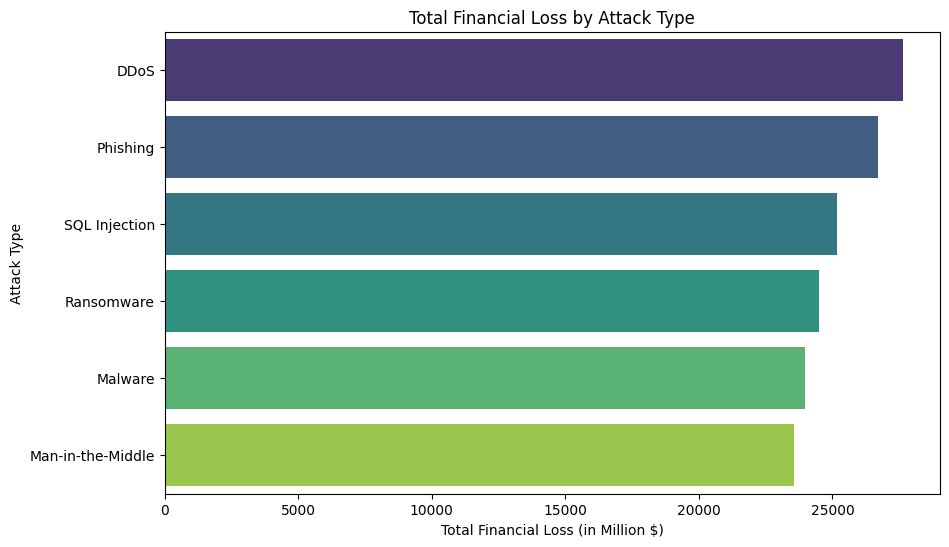


--- Total Financial Loss by Attack Type ---
         Attack Type  Financial Loss (in Million $)
0               DDoS                       27630.92
3           Phishing                       26693.29
5      SQL Injection                       25156.56
4         Ransomware                       24479.32
1            Malware                       23967.95
2  Man-in-the-Middle                       23550.87


In [64]:
# Group by 'Attack Type' and calculate the total financial loss for each type of attack
attack_loss = df.groupby('Attack Type')['Financial Loss (in Million $)'].sum().reset_index()

# Sort by financial loss
attack_loss = attack_loss.sort_values(by='Financial Loss (in Million $)', ascending=False)

# Plot the financial loss by attack type
plt.figure(figsize=(10, 6))
sns.barplot(x='Financial Loss (in Million $)', y='Attack Type', data=attack_loss, palette='viridis')
plt.title('Total Financial Loss by Attack Type')
plt.xlabel('Total Financial Loss (in Million $)')
plt.ylabel('Attack Type')
plt.show()

# Print the table for reference
print("\n--- Total Financial Loss by Attack Type ---")
print(attack_loss)

## 💰 Interpretation of Total Financial Loss by Attack Type Results

**🔍 Overview of Results:**

The table presents the total financial loss (in millions of dollars) attributed to each type of cyberattack reported between 2015 and 2024. The attack types are ranked from the highest to the lowest total financial impact:

* **DDoS:** $27,630.92 million
* **Phishing:** $26,693.29 million
* **SQL Injection:** $25,156.56 million
* **Ransomware:** $24,479.32 million
* **Malware:** $23,967.95 million
* **Man-in-the-Middle:** $23,550.87 million

**🧠 Interpretation & Strategic Insights:**

**DDoS - Surprisingly Highest Total Financial Loss:**

DDoS attacks surprisingly account for the highest total financial loss. While often perceived as primarily disruptive, the cumulative impact of service outages, reputational damage, and the cost of mitigation over the years appears substantial. This highlights the significant economic consequences of availability-focused attacks and the need for robust DDoS protection strategies.

**Phishing - Second Highest, Underscoring Human Vulnerability:**

Phishing attacks, which often target human vulnerabilities, are the second most costly attack type. This underscores the significant financial risks associated with social engineering and the importance of continuous user education and strong email security controls. The success of phishing often leads to further, more damaging attacks like ransomware or data breaches.

**SQL Injection - Significant Impact on Data Integrity and Availability:**

SQL Injection attacks rank third in terms of total financial loss. These attacks can lead to data breaches, data corruption, and service disruption, all of which carry significant financial implications for affected organizations. Secure coding practices and robust database security measures are crucial to mitigate this risk.

**Ransomware - High Cost, but Lower Than Expected:**

While Ransomware is often highlighted for its disruptive and financially damaging nature, it ranks fourth in total financial loss in this dataset. This could suggest that while individual ransomware incidents can be very costly, the overall frequency or the effectiveness of recovery efforts might be factors contributing to its lower ranking compared to DDoS and Phishing in terms of total cumulative loss.

**Malware - Broad Threat with Substantial Economic Impact:**

Malware, a broad category of malicious software, accounts for the fifth-highest total financial loss. Its versatility in achieving various malicious objectives, from data theft to system disruption, contributes to its significant economic impact across numerous incidents.

**Man-in-the-Middle - Impact Through Interception and Manipulation:**

Man-in-the-Middle attacks, which involve intercepting and potentially manipulating communications, result in the lowest total financial loss among the top attack types. While still significant, the financial impact might be more localized or dependent on the sensitivity of the intercepted data.

**📌 Key Strategic Takeaways:**

* **Prioritize DDoS Protection:** Given the surprisingly high total financial loss associated with DDoS attacks, organizations should ensure they have robust strategies in place to prevent and mitigate these attacks, including adequate bandwidth, traffic scrubbing services, and resilient infrastructure.
* **Invest Heavily in Anti-Phishing Measures:** The significant financial impact of Phishing underscores the need for continuous investment in advanced email security solutions, user awareness training, and robust multi-factor authentication to reduce susceptibility to social engineering.
* **Secure Development Practices are Crucial:** The high cost of SQL Injection attacks emphasizes the importance of secure coding practices, regular security audits, and the implementation of Web Application Firewalls (WAFs) to prevent database breaches.
* **Comprehensive Ransomware Strategy:** While not the top in total loss, Ransomware remains a critical threat. Organizations need a multi-faceted strategy including robust backups, effective detection and prevention tools, and well-defined incident response plans.
* **Holistic Malware Defense:** A comprehensive malware defense strategy, encompassing endpoint protection, network monitoring, and proactive threat hunting, is essential to minimize the broad economic impact of various forms of malicious software.
* **Secure Communication Channels:** Implementing and enforcing secure communication protocols and educating users about the risks of Man-in-the-Middle attacks can help reduce their financial impact.

This analysis of total financial loss by attack type provides a valuable high-level perspective for strategic cybersecurity planning and resource allocation, highlighting the attack vectors that have historically inflicted the most economic damage globally.

## 🛡️ Analysis: Effectiveness of Defense Mechanisms by Attack Type (Incident Count)

**❓ Question:**

How many reported incidents of each attack type occurred while different defense mechanisms were in use? This analysis aims to understand the frequency with which various defenses are encountered across different attack vectors.

**🎯 Objective:**

The goal of this analysis is to examine the relationship between attack types and the defense mechanisms reported as being used during those incidents. By counting the number of incidents for each combination, we can gain insights into which defenses are most commonly associated with different types of attacks. This can help identify potential mismatches between deployed defenses and prevalent threats, as well as highlight defenses that might be frequently bypassed or ineffective against specific attack vectors.

**🧠 Code Explanation:**

**1. Grouping by Attack Type and Defense Mechanism:**

The code groups the DataFrame by two columns: `Attack Type` and `Defense Mechanism Used`. It then uses the `.size()` method to count the number of incidents for each unique combination of attack type and defense mechanism. The `.reset_index(name='Number of Incidents')` converts the resulting Series into a DataFrame with columns for 'Attack Type', 'Defense Mechanism Used', and 'Number of Incidents'.

**2. Pivoting the Table:**

The `pivot()` function is used to reshape the DataFrame. 'Attack Type' becomes the index, 'Defense Mechanism Used' becomes the columns, and the 'Number of Incidents' fills the values. `.fillna(0)` replaces any missing values (indicating a defense mechanism was not reported for a specific attack type) with zero. This pivoted table provides a clear matrix showing the number of incidents for each attack type against each defense mechanism.

**3. Data Visualization (Heatmap):**

A heatmap is generated using Seaborn (`sns.heatmap`).

* The `y`-axis represents the `Attack Type`.
* The `x`-axis represents the `Defense Mechanism Used`.
* The `annot=True` parameter displays the number of incidents within each cell of the heatmap.
* The `cmap='coolwarm'` specifies the color scheme, where different colors represent varying numbers of incidents.
* The `fmt='g'` parameter formats the annotations as integers.
* The title and axis labels are set for clarity.
* `plt.show()` displays the generated heatmap.

**4. Printing the Table:**

The pivoted table (`defense_pivot`) is also printed to provide the exact numerical values for the number of incidents for each attack type and defense mechanism combination.

**📈 Expected Insights:**

**Frequency of Defense Mechanisms Across Attack Types:**

The heatmap and the table will illustrate how often different defense mechanisms are reported in conjunction with various attack types. We can expect to observe:

* **Commonly Encountered Defenses:** Defense mechanisms with higher numbers across multiple attack types are likely the most frequently deployed or reported security controls.
* **Defense Specificity (or Lack Thereof):** The data might reveal if certain defense mechanisms are more frequently associated with specific attack types, potentially indicating targeted deployment or relevance. Conversely, a relatively even distribution of a defense mechanism across all attack types might suggest a more general deployment.
* **Potential Ineffectiveness or Bypassing:** High numbers of incidents for a particular attack type despite the reported use of a specific defense mechanism *could* suggest that the defense is not highly effective against that attack, is being bypassed, or was not properly configured or updated. However, it's crucial to remember that this analysis only shows correlation, not causation or effectiveness in preventing the initial breach. The defense might still have mitigated the severity or spread of the attack.

**Strategic Implications:**

This analysis can inform the following strategic considerations:

* **Understanding Deployment Patterns:** Provides insights into how different defense mechanisms are typically deployed across various threat scenarios.
* **Identifying Potential Gaps:** Highlights attack types where reported defenses seem less prevalent, potentially indicating gaps in security coverage.
* **Further Investigation of Ineffective Defenses:** Scenarios where a high number of incidents occur despite the use of a specific defense warrant further investigation into the reasons for the continued success of those attacks. This could lead to re-evaluation of the defense's configuration, efficacy against evolving threats, or the need for supplementary controls.
* **Informing Security Baselines:** Understanding the common defenses encountered during different attacks can help establish security baselines and identify deviations that might indicate weaknesses.

It is important to interpret these results cautiously. The presence of a defense mechanism during an attack doesn't necessarily mean it failed to prevent the attack. It could have been a detection mechanism, a mitigating control, or simply a standard security layer that was present but not the primary focus of the attacker's efforts. Combining this analysis with the financial loss and affected user data provides a more comprehensive understanding of defense effectiveness.

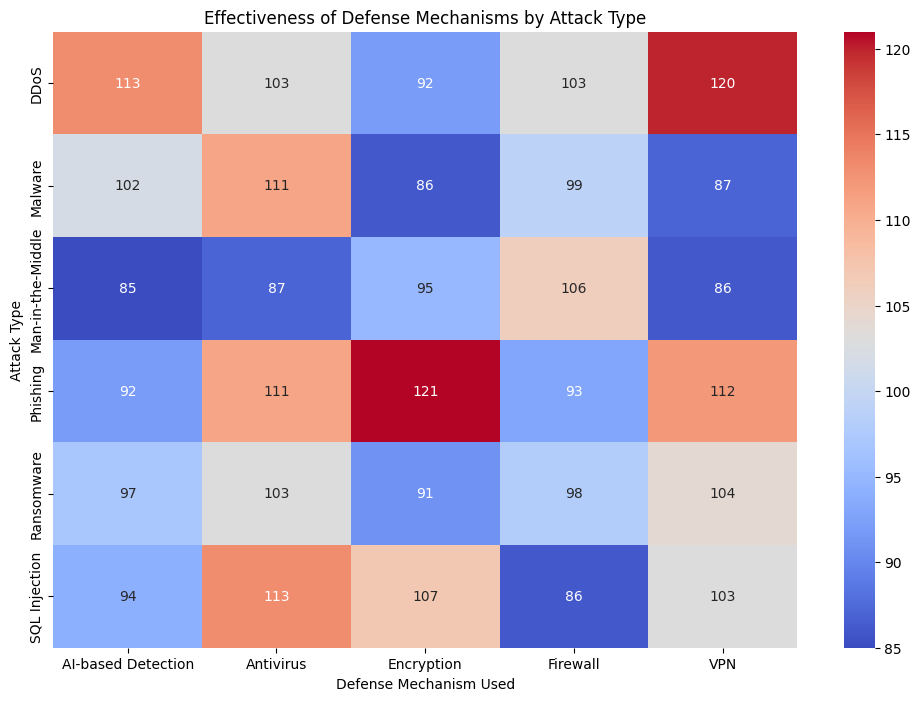


--- Defense Mechanism Effectiveness ---
Defense Mechanism Used  AI-based Detection  Antivirus  Encryption  Firewall  \
Attack Type                                                                   
DDoS                                   113        103          92       103   
Malware                                102        111          86        99   
Man-in-the-Middle                       85         87          95       106   
Phishing                                92        111         121        93   
Ransomware                              97        103          91        98   
SQL Injection                           94        113         107        86   

Defense Mechanism Used  VPN  
Attack Type                  
DDoS                    120  
Malware                  87  
Man-in-the-Middle        86  
Phishing                112  
Ransomware              104  
SQL Injection           103  


In [65]:
# Group by 'Attack Type' and 'Defense Mechanism Used', and calculate the number of incidents
defense_effectiveness = df.groupby(['Attack Type', 'Defense Mechanism Used']).size().reset_index(name='Number of Incidents')

# Pivot to compare defense mechanisms across attack types
defense_pivot = defense_effectiveness.pivot(index='Attack Type', columns='Defense Mechanism Used', values='Number of Incidents').fillna(0)

# Plot a heatmap to show the effectiveness of defense mechanisms by attack type
plt.figure(figsize=(12, 8))
sns.heatmap(defense_pivot, annot=True, cmap='coolwarm', fmt='g')
plt.title('Effectiveness of Defense Mechanisms by Attack Type')
plt.ylabel('Attack Type')
plt.xlabel('Defense Mechanism Used')
plt.show()

# Print the table for reference
print("\n--- Defense Mechanism Effectiveness ---")
print(defense_pivot)


## 🛡️ Interpretation of Defense Mechanism Effectiveness (Incident Count)

**🔍 Overview of Results:**

The table displays the number of reported incidents for each attack type where a specific defense mechanism was reportedly in use between 2015 and 2024. Higher numbers indicate a greater frequency of that defense mechanism being associated with that particular attack type.

**🧠 Interpretation & Strategic Insights:**

**Ubiquitous Defenses:**

* **Antivirus** and **Firewall** show relatively high incident counts across most attack types, suggesting their widespread deployment as foundational security controls. Their presence doesn't necessarily indicate ineffectiveness, but rather their common use as baseline defenses that attackers frequently encounter (and sometimes bypass).
* **VPN** also shows a significant number of incidents across various attack types, likely reflecting its common use for secure remote access and its potential presence during various stages of an attack.

**Defense Associations with Specific Attack Types:**

* **DDoS:** VPN has the highest association with DDoS incidents, followed by AI-based Detection and Firewall. This might suggest that organizations frequently rely on these mechanisms to mitigate or manage the impact of denial-of-service attacks.
* **Malware:** Antivirus has the highest association with Malware incidents, which is expected as antivirus is a primary defense against malicious software. Firewall also shows a high count, indicating its role in potentially blocking initial malware delivery or communication.
* **Man-in-the-Middle:** Firewall has the highest association with Man-in-the-Middle attacks. This might reflect the use of firewalls to monitor and control network traffic, potentially detecting suspicious activity associated with MITM attempts. Encryption also shows a relatively high count, suggesting its use in protecting data confidentiality even if a MITM attack occurs.
* **Phishing:** Encryption has the highest association with Phishing incidents. This is interesting as encryption doesn't directly prevent phishing emails but would protect the confidentiality of data if a phishing attack leads to data exfiltration. Antivirus and VPN also show high counts, likely reflecting their general deployment.
* **Ransomware:** VPN has the highest association with Ransomware incidents, followed by Antivirus and Firewall. This might indicate that attackers often attempt to exploit vulnerabilities in VPN connections or that these defenses are commonly present but not always effective in preventing ransomware execution or propagation.
* **SQL Injection:** Antivirus has the highest association with SQL Injection incidents, followed by Encryption and VPN. Firewalls show a lower count, which might suggest that web application firewalls (WAFs), a more specific defense against web-based attacks like SQL Injection, are not as consistently reported in this dataset or that these attacks often bypass network-level firewalls.

**Potential Areas for Strategic Focus:**

* **Investigate High Incident Counts with Limited Effectiveness (from previous financial loss analysis):** For instance, if a defense mechanism shows a high number of associated incidents for a specific attack type *and* a high average financial loss for that combination (from earlier analysis), it warrants a deeper look into its effectiveness and potential for improvement or augmentation.
* **Understand the Role of VPN in Ransomware and DDoS:** The high association of VPN with both DDoS and Ransomware incidents suggests a need to understand why it's frequently present in these scenarios. Is it a primary target, a common security layer that's bypassed, or used in response?
* **Consider WAF Deployment for Web Application Attacks:** The relatively lower association of Firewalls with SQL Injection might indicate an opportunity to emphasize the deployment and reporting of Web Application Firewalls (WAFs) as a more targeted defense against such attacks.
* **Evaluate the Effectiveness of Common Defenses:** The widespread presence of Antivirus and Firewalls across various attack types necessitates continuous evaluation of their effectiveness against evolving threats and the need for complementary security controls.

**Important Note:** This analysis only reflects the co-occurrence of attack types and defense mechanisms in reported incidents. It does not directly indicate the effectiveness of the defense in preventing the attack. A high number of incidents with a particular defense might simply mean that the defense is commonly deployed and thus frequently encountered by attackers. To truly assess effectiveness, this data should be correlated with the success rate of attacks and the resulting impact (financial loss, affected users), as explored in previous analyses.

## 🔥 Attack Source Distribution by Industry — Code Analysis
🎯 Objective:
The purpose of this analysis is to understand how different attack sources (e.g., nation-states, insider threats, hacker groups) are distributed across various industries. This helps identify which industries are more vulnerable to specific types of threat actors.

🔍 Expected Insights:
Industries like banking, government, or IT may show high exposure to nation-state or hacker group attacks.

Insider threats might be more prevalent in sectors like healthcare or education, where internal access is widespread.

The heatmap provides a visual correlation between industries and the types of actors targeting them.

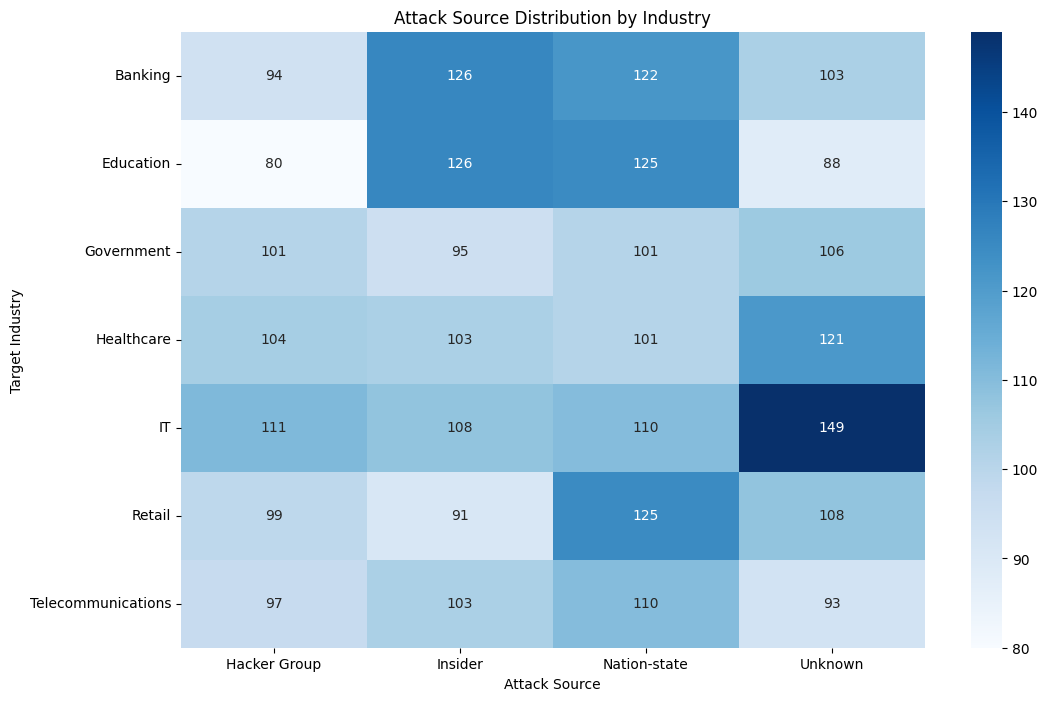


--- Attack Source Distribution by Industry ---
Attack Source       Hacker Group  Insider  Nation-state  Unknown
Target Industry                                                 
Banking                       94      126           122      103
Education                     80      126           125       88
Government                   101       95           101      106
Healthcare                   104      103           101      121
IT                           111      108           110      149
Retail                        99       91           125      108
Telecommunications            97      103           110       93


In [67]:
# Group by 'Target Industry' and 'Attack Source', then count the number of incidents
industry_attack_source = df.groupby(['Target Industry', 'Attack Source']).size().reset_index(name='Number of Incidents')

# Pivot the table to show attack sources across different industries
attack_source_pivot = industry_attack_source.pivot(index='Target Industry', columns='Attack Source', values='Number of Incidents').fillna(0)

# Plot a heatmap to show the attack source distribution across industries
plt.figure(figsize=(12, 8))
sns.heatmap(attack_source_pivot, annot=True, cmap='Blues', fmt='g')
plt.title('Attack Source Distribution by Industry')
plt.ylabel('Target Industry')
plt.xlabel('Attack Source')
plt.show()

# Print the table for reference
print("\n--- Attack Source Distribution by Industry ---")
print(attack_source_pivot)


## **Analysis of Attack Source Distribution by Industry**


### 🔍 **General Overview**

The table presents the number of incidents attributed to each type of cyberattack source (Hacker Groups, Insiders, Nation-State, Unknown) across various targeted industries between 2015 and 2024. Strategic insights can be derived from this distribution to understand the threat landscape faced by each sector.

### 🧠 **Key Observations by Industry:**

#### 🔐 **Banking Sector:**
- **Insider threats** are the highest with **126 incidents**.
- Followed by **Nation-State attacks** at **122 incidents**.
- The prominence of insider threats highlights the need for strict internal monitoring and strong security awareness among employees.

#### 🎓 **Education Sector:**
- Almost equal numbers of **Nation-State (125)** and **Insider (126)** attacks.
- Indicates this sector is targeted by **advanced actors (possibly for data gathering or espionage)**, in addition to internal weaknesses.

#### 🏛️ **Government Sector:**
- The threats are relatively evenly distributed, with a slight increase in **Unknown (106)** and **Hacker Groups (101)**.
- This balance suggests the public sector is a target from all directions, requiring **multi-layered defense strategies**.

#### 🏥 **Healthcare Sector:**
- **Unknown sources** lead with **121 incidents**, possibly indicating **a lack of detection and forensic capabilities**.
- Nation-State and Insider threats are also high (~101-103), which is alarming due to the sensitivity of medical data.

#### 🧑‍💻 **IT Sector:**
- **Unknown** is the highest with **149 incidents**, the highest value in the table.
- Suggests that attacks on the IT sector are **highly advanced and often well-obfuscated**.
- Other sources are also close (~110), reflecting a **diverse range of threats**.

#### 🛒 **Retail Sector:**
- High number of **Nation-State attacks (125)** and **Unknown sources (108)**.
- Indicates that this industry is not only a financial target but may also be compromised to harvest user data or disrupt supply chains.

#### 📡 **Telecommunications Sector:**
- Threats are almost evenly distributed.
- Due to its critical infrastructure role, this pattern shows **a high level of interest from all attacker categories**.

---

### 🎯 **Strategic Conclusions:**

1. **Insider threats** pose significant risks to **critical sectors (e.g., banking and education)**.
2. **Nation-State attacks** are widespread across all industries, emphasizing their geopolitical nature.
3. **Unknown attack sources** are alarmingly high in **IT and Healthcare**, pointing to gaps in detection and attribution.
4. No industry is immune to **multi-source threats**, reinforcing the need for **comprehensive response strategies** that combine technology, awareness training, and robust policy frameworks.

## 🔍 **Strategic Analysis: Mapping Security Vulnerabilities to Attack Types**

### **🎯 Question:**
Which types of security vulnerabilities are most commonly associated with different types of cyberattacks?

### **🧭 Objective:**
The goal of this analysis is to uncover the relationship between **security vulnerabilities** and **cyberattack techniques**. By identifying which vulnerabilities are frequently exploited in specific attack types (e.g., ransomware, phishing, DDoS), security teams can:
- Better prioritize patching and mitigation strategies,
- Understand attackers' preferred exploitation paths,
- Develop targeted defenses for high-risk combinations.

### **⚙️ Code Function Overview:**

- **Data Grouping**: The code groups incidents by two key fields: `Security Vulnerability Type` and `Attack Type`, then counts the number of incidents for each pair.
- **Pivot Table**: It restructures the data into a matrix format where rows represent vulnerability types and columns represent attack types. The values represent the number of incidents for each pair.
- **Heatmap Visualization**: A heatmap is generated to easily visualize which combinations are most frequent, using color intensity to highlight concentration.
- **Data Output**: The final pivot table is also printed for reference.

### **🔑 Expected Insights:**

- **High-Risk Pairings**: The heatmap will reveal the strongest associations between specific vulnerability types and attack methods (e.g., *Zero-day* ↔ *Malware*, *Social Engineering* ↔ *Phishing*).
- **Attack Pattern Understanding**: Security teams can anticipate likely attack vectors based on vulnerability exposure.
- **Strategic Hardening**: Organizations can focus defense investments on blocking attack types that most commonly target the vulnerabilities they are most exposed to.

### **📈 Example Applications:**
- If *Unpatched Software* is mostly linked with *Ransomware* and *Malware*, then keeping systems updated becomes a clear defensive priority.
- If *Weak Passwords* are frequently exploited via *Man-in-the-Middle* attacks, enforcing MFA and stronger password policies becomes critical.


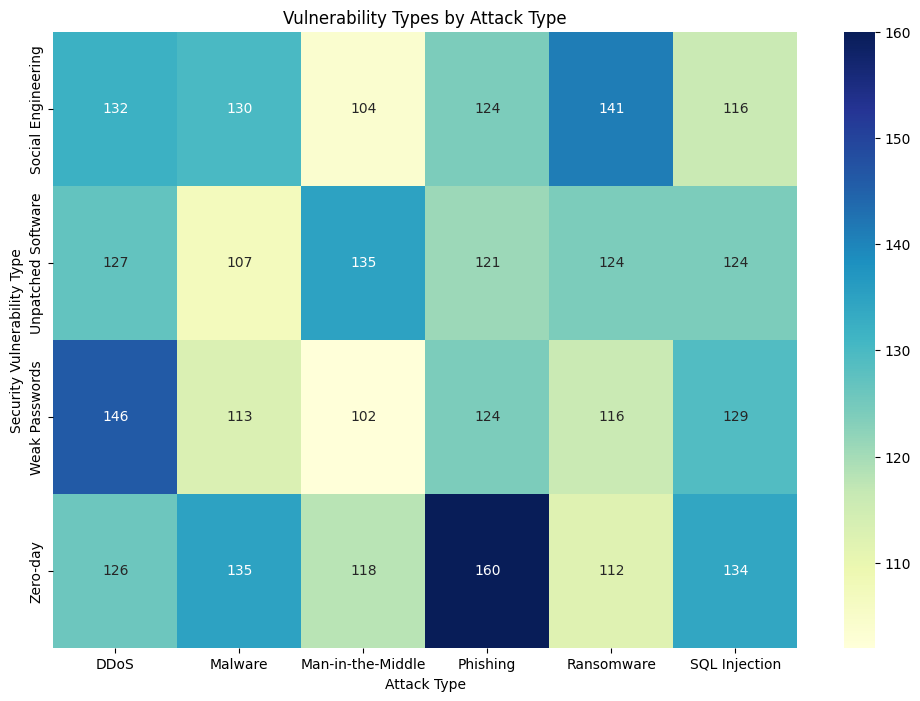


--- Vulnerability Types by Attack Type ---
Attack Type                  DDoS  Malware  Man-in-the-Middle  Phishing  \
Security Vulnerability Type                                               
Social Engineering            132      130                104       124   
Unpatched Software            127      107                135       121   
Weak Passwords                146      113                102       124   
Zero-day                      126      135                118       160   

Attack Type                  Ransomware  SQL Injection  
Security Vulnerability Type                             
Social Engineering                  141            116  
Unpatched Software                  124            124  
Weak Passwords                      116            129  
Zero-day                            112            134  


In [68]:
# Group by 'Security Vulnerability Type' and 'Attack Type', then count the number of incidents
vulnerability_attack = df.groupby(['Security Vulnerability Type', 'Attack Type']).size().reset_index(name='Number of Incidents')

# Pivot the table to show vulnerability types across attack types
vulnerability_pivot = vulnerability_attack.pivot(index='Security Vulnerability Type', columns='Attack Type', values='Number of Incidents').fillna(0)

# Plot a heatmap to show the distribution of vulnerabilities across attack types
plt.figure(figsize=(12, 8))
sns.heatmap(vulnerability_pivot, annot=True, cmap='YlGnBu', fmt='g')
plt.title('Vulnerability Types by Attack Type')
plt.ylabel('Security Vulnerability Type')
plt.xlabel('Attack Type')
plt.show()

# Print the table for reference
print("\n--- Vulnerability Types by Attack Type ---")
print(vulnerability_pivot)


### **Analysis of Vulnerability Types by Attack Type:**

The table presents the distribution of **security vulnerabilities** across different **attack types**. This analysis provides critical insights into which vulnerabilities are most commonly targeted by each type of cyberattack. Here's a breakdown of the results:

---

### **Key Observations:**

1. **Social Engineering**:
   - **Most Targeted Attacks**: The highest number of incidents involving **Social Engineering** were seen with **DDoS** (132 incidents), followed closely by **Ransomware** (141 incidents).
   - **Potential Insight**: Attackers leveraging social manipulation (e.g., phishing or baiting) are often targeting broader infrastructure (DDoS) and extortion attempts (Ransomware).

2. **Unpatched Software**:
   - **Diverse Exploitation**: **Unpatched Software** is heavily targeted across various attack types, with significant numbers across **Man-in-the-Middle** (135 incidents), **SQL Injection** (124 incidents), and **Ransomware** (124 incidents).
   - **Critical Insight**: Vulnerabilities due to unpatched software are often exploited across a wide array of attack types. This reinforces the importance of consistent patching and updating to prevent diverse attack methods.

3. **Weak Passwords**:
   - **Widespread Impact**: **Weak Passwords** are most targeted in **DDoS** (146 incidents), followed by **Ransomware** (116 incidents) and **SQL Injection** (129 incidents).
   - **Insight**: Weak passwords are a frequent entry point for attackers. It’s particularly common in **DDoS** attacks where attackers can leverage brute-force methods to overwhelm systems or gain unauthorized access.

4. **Zero-day Vulnerabilities**:
   - **Highest Impact in Ransomware**: **Zero-day vulnerabilities** are predominantly associated with **Phishing** (160 incidents) and **Malware** (135 incidents), followed by **Ransomware** (112 incidents).
   - **Insight**: Zero-day vulnerabilities, being unknown and unpatched, are critical in high-impact attacks like **Malware** and **Phishing**, often used in sophisticated campaigns for maximum damage.

---

### **Strategic Insights:**

1. **Focus Areas for Defense**:
   - Given the broad exploitation of **Unpatched Software**, prioritizing a patch management system and regular software updates could reduce exposure to a variety of attacks (e.g., **SQL Injection**, **Ransomware**).
   - Strengthening password policies and deploying Multi-Factor Authentication (MFA) can help mitigate **Weak Passwords** vulnerabilities, particularly in **DDoS** and **Ransomware** scenarios.

2. **Advanced Threat Detection**:
   - Enhanced monitoring and intrusion detection systems should focus on **Zero-day** vulnerabilities, especially since they lead to **Malware** and **Phishing** attacks. These attacks can be difficult to detect without advanced AI-based detection mechanisms.

3. **Tailored Mitigation Strategies**:
   - **Social Engineering** attacks might require increased awareness and training, especially in the context of **Phishing** and **Ransomware**, where human manipulation plays a significant role.
   - **Zero-day** vulnerabilities necessitate investment in real-time threat intelligence and early-warning systems, as these vulnerabilities are not easily mitigated by traditional means.

### **Conclusion:**

This report provides an in-depth analysis of global cyberattacks from 2015 to 2024, offering insights into the most targeted countries, industries, attack types, and vulnerabilities. The findings highlight several key patterns, such as the significant role played by **Social Engineering** and **Unpatched Software** in facilitating cyberattacks, as well as the prevalence of **DDoS** and **Phishing** attacks. Additionally, it is evident that certain industries, such as **Banking** and **Healthcare**, are disproportionately targeted, with **Nation-state actors** being a dominant source of cyberattacks. 

The data also emphasizes the importance of improving defenses against **Zero-day vulnerabilities**, **Weak Passwords**, and **Social Engineering** tactics. As cyber threats evolve and grow in complexity, the need for robust, proactive cybersecurity measures is more critical than ever.

### **Strategic Recommendations:**

Based on the insights gathered, here are several strategic recommendations for improving cybersecurity measures:

1. **Prioritize Patch Management and Software Updates**:
   - **Unpatched Software** is a key vulnerability exploited across multiple attack types. Regular and timely updates to software and systems should be prioritized to prevent exploitation through vulnerabilities that could lead to attacks such as **SQL Injection** and **Ransomware**.

2. **Enhance Password Security**:
   - With **Weak Passwords** being a frequent entry point for cyberattacks, organizations should enforce strong password policies, implement **Multi-Factor Authentication (MFA)**, and encourage the use of password managers to reduce the risk of unauthorized access through brute-force or credential stuffing techniques.

3. **Deploy Advanced Threat Detection Systems**:
   - **Zero-day vulnerabilities** require rapid identification and mitigation. Investing in real-time threat intelligence, **AI-based detection**, and automated incident response systems will help mitigate the impact of unknown vulnerabilities and prevent them from being exploited in **Malware** and **Phishing** attacks.

4. **Strengthen Defense against Social Engineering Attacks**:
   - Since **Social Engineering** techniques are frequently used in attacks like **Phishing** and **Ransomware**, organizations should conduct regular cybersecurity awareness training for employees. This training should include recognizing suspicious communications and practicing good cyber hygiene.

5. **Industry-Specific Cybersecurity Protocols**:
   - Given the disproportionate number of cyberattacks in industries such as **Banking**, **Healthcare**, and **IT**, it is crucial for organizations in these sectors to implement industry-specific security protocols. These should include data encryption, network segmentation, and advanced fraud detection mechanisms to better safeguard sensitive information.

6. **Strengthen Incident Response and Collaboration**:
   - Cyberattacks are increasingly sophisticated and multifaceted. Organizations should develop and regularly test their incident response plans to ensure they can quickly and effectively mitigate the effects of attacks. Collaboration with other industries and governments, especially in sharing threat intelligence, can significantly improve the overall defense posture.

7. **Invest in Next-Generation Firewalls and AI-Driven Security Solutions**:
   - The analysis indicates that traditional defense mechanisms, like firewalls and antivirus solutions, still play a role but may not be sufficient against evolving threats. Integrating next-generation firewalls, **AI-driven security solutions**, and behavioral analytics can help detect anomalies and stop attacks before they escalate.

By implementing these strategic recommendations, organizations can strengthen their cybersecurity posture, reduce the risk of data breaches, and enhance their ability to respond to the growing and evolving threat landscape. Effective defense against cyberattacks requires a holistic, layered approach that includes both technological solutions and proactive training to prepare for the next wave of cyber threats.